# Continuous prediction of geomagnetic indices 

In [1]:
# Conda dependencies are listed under environment.yml
import os
import sys
import copy
from datetime import datetime, timedelta
import getpass
import logging
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import num2date, date2num
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

import numpy as np
import pdb
import pickle
import requests
import scipy.io
from scipy import stats
import scipy
import warnings
from sunpy.time import parse_time
import sklearn
import pandas as pd
import matplotlib.dates as mdates
import astropy.units as u
from scipy.optimize import curve_fit, least_squares, minimize
import plotly.express as px
import plotly.graph_objects as go
from datetime import timezone
from itertools import groupby
from operator import itemgetter

from matplotlib.colors import TwoSlopeNorm

import time
import numba
from numba import njit, prange
from astropy.time import Time, TimeDelta
from sunpy.coordinates import HeliographicStonyhurst, HeliocentricEarthEcliptic
import astrospice
#from heliocats import data as hd
from functions.data import SatData
from functions.data import PositionData
import urllib
import multiprocess as mp
#import functions_sta as fs

import seaborn as sns
from sklearn.metrics import mean_squared_error
#from heliocats import plot as hp
#import heliocats.data as hd

#import heliosat
#import predstorm as ps
from functions import data as data_sat
from functions import predict as pred
#from predstorm.config.conscnts import AU, dist_to_L1
#from predstorm.predict import dst_loss_function

warnings.filterwarnings('ignore') # some numpy mean-of-empty-slice runtime warnings

c0 = "xkcd:black"
c1 = "xkcd:magenta"
c2 = '#FFC20A' #"xkcd:orange"
c3 = '#0C7BDC' #"xkcd:azure"
c4 = "xkcd:green"

#sns.set_style('whitegrid', {'xtick.bottom': True, 'grid.color': 'gainsboro'})
#sns.set_context('paper')

sns.set_style('whitegrid')
sns.set_context('paper')

data_path = 'data/'

## Some functions

In [2]:
def interp_nans(sc_in, single=False):
    sc = copy.deepcopy(sc_in)
    
    n = len(sc)

    # Use index positions as the x-axis (since time steps are regular)
    x = np.arange(n)
    
    if single:
        mask = ~np.isnan(sc)
        
        if np.sum(mask) >= 2:  # Need at least 2 points to interpolate
            # Interpolate over valid points
            sc = np.interp(x, x[mask], sc[mask])
        else:
            print(f"Skipping '{key}': not enough valid data to interpolate.")
            
    else:
        keys_to_interp = [name for name in sc.dtype.names if name != 'time']

        for key in keys_to_interp:
            y = sc[key]

            if y.dtype.kind in 'f':  # Only interpolate float fields
                mask = ~np.isnan(y)

                if np.sum(mask) >= 2:  # Need at least 2 points to interpolate
                    # Interpolate over valid points
                    sc[key] = np.interp(x, x[mask], y[mask])
                else:
                    print(f"Skipping '{key}': not enough valid data to interpolate.")

                
    return sc

    
def interp_to_time(sc_in, time_shift_seconds, res=1):

        
    #define time grid here so that it is the same for all.
    #use more than just sigma uncertainty but rather all ensembles for binned data.
    #and then use the same ensemble size for SYM-H prediction and calculate error as for INGRID event.
    #ask Chris if this strategy is legit.

    sc = copy.deepcopy(sc_in)
    sc.time = [sc_in.time[i]+timedelta(seconds=time_shift_seconds[i].astype(float)) for i in range(len(sc_in.time))]#+np.array(random_time[:,j], dtype='timedelta64[s]'


    t_start=datetime(2022,11,11)#sc.time[0].astype(datetime)
    t_end=datetime(2024,6,5)#sc.time[-1].astype(datetime)

    t1=sc.time

    format_str = '%Y-%m-%d %H:%M'  
    t0 = datetime.strptime(datetime.strftime(t_start, format_str), format_str) #+timedelta(minutes=1)

    time_all = [ t0 + timedelta(minutes=res*n) for n in range(int ((t_end - t_start).days*(60./res)*24)+1)]
    time_mat=mdates.date2num(time_all) 

    sc_rec=np.zeros(np.size(time_all),dtype=[ ('time',object),('bx', float),('by', float),\
            ('bz', float),('bt', float),('r', float),('lat', float),('lon', float),\
            ('x', float),('y', float),('z', float),('vx', float),\
            ('vy', float),('vz', float),('vt', float),('np', float), ('symh', float) ] ) 
            #('tp', float),\

    sc_rec=sc_rec.view(np.recarray)  

    time_m_num=mdates.date2num(t1) #make date number

    sc_rec.time=time_all


    sc_rec.np=np.interp(time_mat, time_m_num, sc.np)
    #sc_rec.tp=np.interp(time_mat, time_m_num, sc.tp) 
    sc_rec.vt=np.interp(time_mat, time_m_num, sc.vt)

    sc_rec.bx=np.interp(time_mat, time_m_num, sc.bx)
    sc_rec.by=np.interp(time_mat, time_m_num, sc.by)
    sc_rec.bz=np.interp(time_mat, time_m_num, sc.bz)
    sc_rec.bt=np.interp(time_mat, time_m_num, sc.bt)

    sc_rec.x=np.interp(time_mat, time_m_num, sc.x)
    sc_rec.y=np.interp(time_mat, time_m_num, sc.y)
    sc_rec.z=np.interp(time_mat, time_m_num, sc.z)

    sc_rec.symh=np.zeros(len(time_all))

    sc_rec.r=np.interp(time_mat, time_m_num, sc.r)
    sc_rec.lon=np.interp(time_mat, time_m_num, sc.lon)
    sc_rec.lat=np.interp(time_mat, time_m_num, sc.lat)

    sc_rec_interp = interp_nans(sc_rec)

    return sc_rec_interp

In [3]:
def despike_speed(vt_in):


    #set all nan to 0 in the v gradient array
    v1=copy.deepcopy( np.abs( np.gradient(vt_in)   ))
    vt = copy.deepcopy(vt_in)
    vnan_ind=np.where(np.isnan(v1)==True)[0]
    v1[vnan_ind]=0
 
    peaks, properties = scipy.signal.find_peaks(v1, prominence=40, width=(1,10)) #prom=40, width=(1,10) 
    indices = np.where(v1>400)[0]
    print(len(indices))
    vt[indices]=np.nan
    vt[vt>1200]=np.nan            #added this very hard cutoff.. but it fits science data much better.


    for i in np.arange(len(peaks)):
        width=int(np.ceil(properties['widths'])[i])   
        vt[peaks[i]-width:peaks[i]+width]=np.nan


    #print(properties['widths'])
    
    return vt


def despike_density(den_in):


    #set all nan to 0 in the v gradient array
    den1=copy.deepcopy( abs( np.gradient(den_in)   ))
    den = copy.deepcopy(den_in)
    den[den>100]=np.nan
    den1nan_ind=np.where(np.isnan(den1)==True)[0]
    den1[den1nan_ind]=0
 
    peaks, properties = scipy.signal.find_peaks(den1, prominence=10, width=(1, 50))
    den[np.where(den1>10)]=np.nan
    den1[np.where(den1>10)]=np.nan

    for i in np.arange(len(peaks)):
         width=int(np.ceil(properties['widths'])[i])
         #print(width)   
         den[peaks[i]-width:peaks[i]+width]=np.nan

    return den


## DATA READING

In [4]:
# ------ Load Wind, STEREO-A (science) and OMNI high resolution data ------

print('load ACE/DSCOVR, STEREO-A and OMNI data')

l1_input_heeq = pickle.load(open(data_path+'l1_HEEQ_20221111_20240604.p', 'rb'))
l1_input_in = pickle.load(open(data_path+'noaa_20221111_20240604_B_GSM_Coords_GSE.p', 'rb'))

sc_beacon = pickle.load(open(data_path+'sta_beacon_20221111_20240604_B_GSM_Coords_GSE_new.p', 'rb'))
sc_science = pickle.load(open(data_path+'sta_science_20221111_20240604_B_GSM_Coords_GSE_new.p', 'rb'))
sc_input_heeq = pickle.load(open(data_path+'sta_science_HEEQ_20221111_20240604.p', 'rb'))

omni_input = pickle.load(open(data_path+'omni_20221111_20240604.p', 'rb'))

#l1_pos = pickle.load(open(data_path+'l1_pos_GSE_20221111_20240604.p', 'rb'))
earth_pos = pickle.load(open(data_path+'earth_pos_HEEQ_20221111_20240604.p', 'rb'))

print('done')

load ACE/DSCOVR, STEREO-A and OMNI data
done


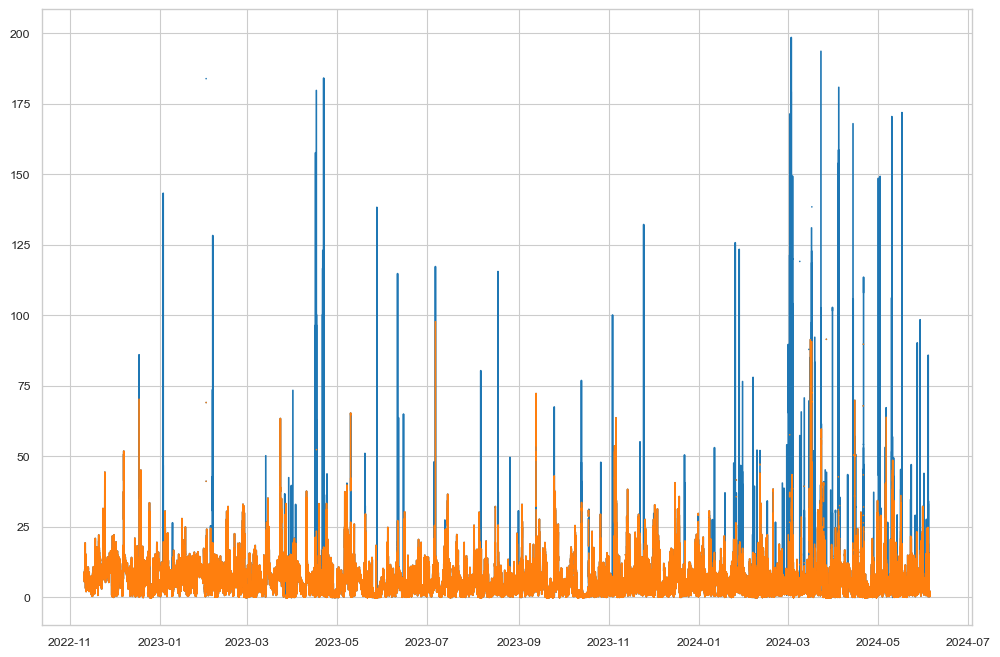

In [5]:
l1_input_np = despike_density(l1_input_in.np)

plt.figure(figsize=(12,8))
plt.plot(l1_input_in.time, l1_input_in.np)
plt.plot(l1_input_in.time, l1_input_np)

l1_input=copy.deepcopy(l1_input_in)
l1_input.np = l1_input_np

In [6]:
beacon = True
use_plasma = True

if beacon:
    sc_input = sc_beacon
    #[delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc, delta_t_mean_sc, delta_t_std_sc] = pickle.load(open(data_path+'mean_time_shift_and_sigma_beacon.p', 'rb'))
    if use_plasma:
        sc_input.np = sc_science.np
        sc_input.vt = sc_science.vt

else:
    sc_input = sc_science
    #[delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc, delta_t_mean_sc, delta_t_std_sc] = pickle.load(open(data_path+'mean_time_shift_and_sigma_science.p', 'rb'))
    
#pickle.dump(sc_input, open(data_path+'sta_beacon_plasma_science_20221111_20240605_GSM.p', 'wb'))

In [7]:
if beacon:
    if use_plasma==False:
        #get rid of weird spikes in stereo-a beacon speed and density data

        speed_sc = despike_speed(sc_input.vt)
        den_sc = despike_density(sc_input.np)

        sc_input.vt = speed_sc
        sc_input.np = den_sc

        plt.figure(1, figsize=(15,8))
        plt.plot(sc_science.time, sc_science.vt, 'bo')
        plt.plot(sc_input.time, speed_sc, 'ro', alpha=0.6)

        plt.figure(2, figsize=(15,8))
        plt.plot(sc_input.time, abs(np.gradient(sc_input.vt)))

        plt.figure(3, figsize=(15,8))
        plt.plot(sc_science.time, sc_science.np)
        plt.plot(sc_input.time, den_sc, alpha=0.6)
        #plt.plot(sc_input.time, abs(np.gradient(sc_input.np)))

0.2648621807780189


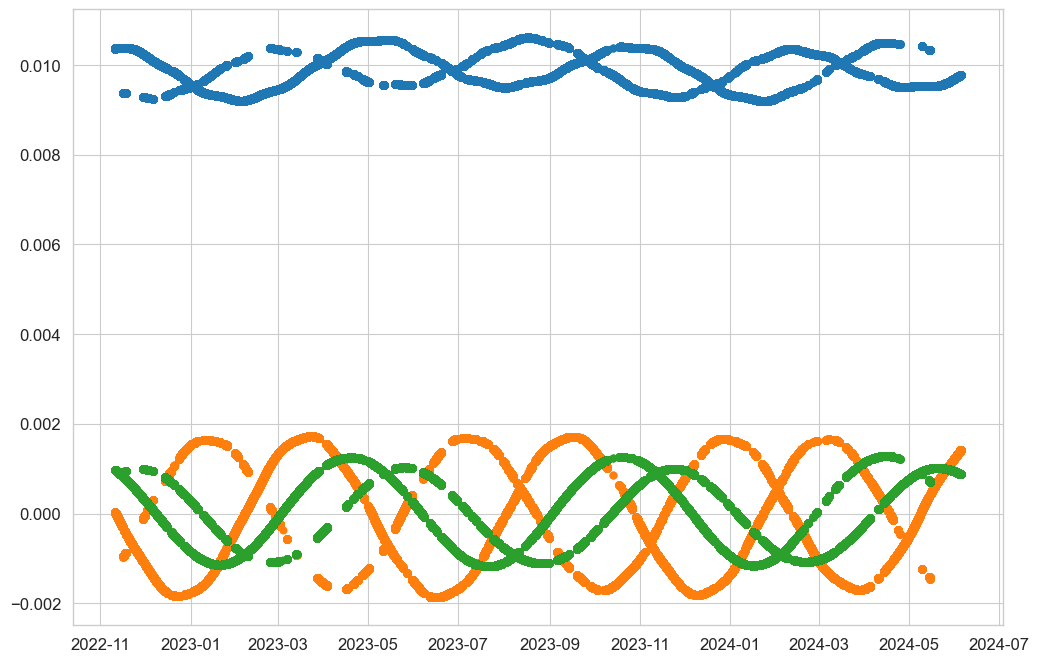

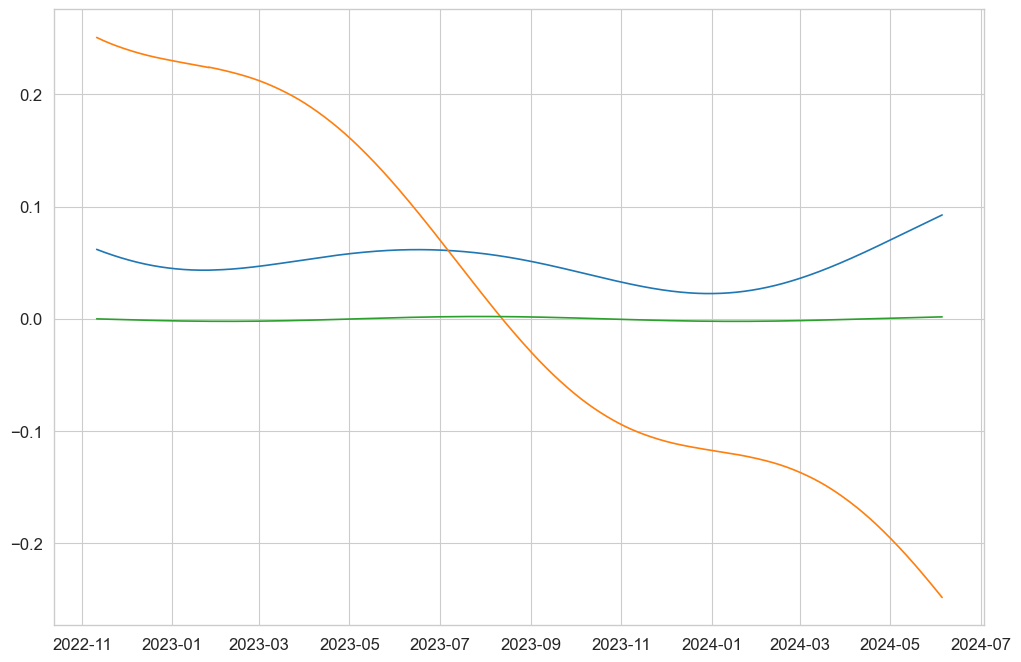

In [8]:
plt.figure(1, figsize=(12,8))
plt.plot(l1_input.time, l1_input.x*u.km.to(u.au), 'o')
plt.plot(l1_input.time, l1_input.y*u.km.to(u.au), 'o')
plt.plot(l1_input.time, l1_input.z*u.km.to(u.au), 'o')
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)


plt.figure(2, figsize=(12,8))
plt.plot(sc_input.time, sc_input.x*u.km.to(u.au))
plt.plot(sc_input.time, sc_input.y*u.km.to(u.au))
plt.plot(sc_input.time, sc_input.z*u.km.to(u.au))
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)

print(np.max(sc_input.r))

In [9]:
#SOME GLOBAL EXPANSION CALCULATIONS

#print(np.abs(np.max(sc_input.x)*u.km.to(u.au))-np.abs(np.max(l1_input.x)*u.km.to(u.au)))
bt_max_time = sc_input_heeq.time[sc_input_heeq.bt==np.abs(np.nanmax(sc_input_heeq.bt))]
r_bt_max_sc = sc_input_heeq.r[sc_input_heeq.bt==np.abs(np.nanmax(sc_input_heeq.bt))]
print(bt_max_time)
bt_max = np.nanmax(sc_input_heeq.bt)
print(bt_max)
r_bt_max_l1 = l1_input_heeq.r[l1_input_heeq.time==bt_max_time]
#print(r_bt_max_l1)

b_scaled_max = bt_max*(r_bt_max_l1 / r_bt_max_sc)**(-1.66)
#print(np.round(b_scaled_max[0],1))
print(np.round((bt_max-b_scaled_max[0])/bt_max*100,1))

ratio = l1_input_heeq.r[-1] / sc_input_heeq.r[-1]
print(ratio)

b_scaled = sc_input.bt[-1]*(ratio)**(-1.66)

[datetime.datetime(2024, 5, 10, 23, 10)]
66.64588572184245
7.2
1.0523695441330951


482.1000061035156


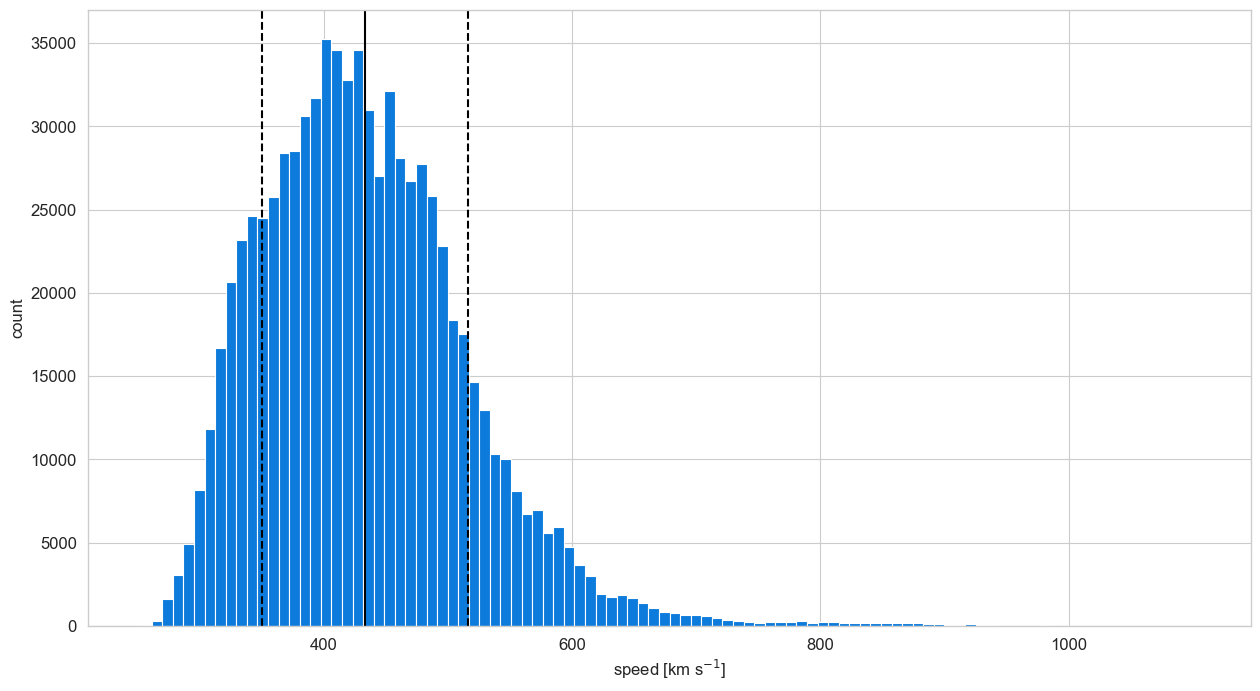

In [10]:
#plot speed distribution for L1 data

vt_in = l1_input.vt.astype(np.float32)
plt.figure(1,figsize=(15,8),dpi=100)
plt.hist(vt_in,100,color=c3)
plt.axvline(np.nanmean(vt_in), color=c0, linestyle='-', linewidth=1.5)
#plt.axvline(np.median(V_wind), color='k', linestyle='dashed', linewidth=1)
plt.axvline(np.nanmean(vt_in)+np.nanstd(vt_in), color=c0, linestyle='dashed', linewidth=1.5)
plt.axvline(np.nanmean(vt_in)-np.nanstd(vt_in), color=c0, linestyle='dashed', linewidth=1.5)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.xlabel('speed [km s$^{-1}$]', fontsize=12)
plt.ylabel('count', fontsize=12)

print(np.nanpercentile(vt_in, 75))

#print(np.std(vt))

### Calculate time-shift to Earth for L1 and STEREO-A data

Time shift is calculated using an euqation given in the OMNI low res data documentation (King & Papitashvili, 2005), Equ. 1 & 2 in current work.

In [11]:
@njit(parallel=True)
def compute_delta_t(x, y, vt, V1, W1, Vearth=30.):
    N = len(x)
    n_ensemble = V1.shape[0]
    
    #delta_t_mean = np.zeros(N, dtype=np.float32)
    #delta_t_std = np.zeros(N, dtype=np.float32)
    delta_t_all = np.zeros((N, n_ensemble), dtype=np.float32)  # Preallocate 2D array
    
    for i in prange(N):
        #delta_t_all = np.empty(n_ensemble, dtype=np.float32)
        xi = x[i]
        yi = y[i]
        vti = vt[i]

        for j in range(n_ensemble):
            v1 = V1[j]
            W = W1[j]
            
            denom = (1 - (Vearth * W / v1))
            if denom == 0:  # avoid division by zero
                denom = 1e-6

            #delta_t_all[j] = (xi / v1) * ((1 + (yi * W / xi)) / denom)
            delta_t_all[i, j] = (xi / v1) * ((1 + (yi * W / xi)) / denom)
            
        #delta_t_mean[i] = np.mean(delta_t_all, axis=1)
        #delta_t_std[i] = np.std(delta_t_all, axis=1)

    return delta_t_all#, delta_t_mean, delta_t_std

In [12]:
calc_time_shift = False
n_ensemble = 2500
Vearth = 30.

In [13]:

# Generate ensemble parameters
ratio = np.random.normal(0.5, 0.1, n_ensemble).astype(np.float32)
#vt = np.nanpercentile(vt_in, 75)
Vmean_l1 = np.nanmean(vt_in).astype(np.float32)
Vstd_l1 = np.nanstd(vt_in).astype(np.float32)
V_ambwind = np.random.normal(428, 428 * 0.1, n_ensemble).astype(np.float32)
V1_l1 = np.random.normal(Vmean_l1, Vstd_l1, n_ensemble).astype(np.float32)
#W1_l1 = np.tan(ratio * np.arctan(V1_l1 / V_ambwind)).astype(np.float32)
#W_l1 = np.tan(0.5 * np.arctan(Vmean_l1 / 428))
#new:
W1_l1 = np.tan(ratio * np.arctan(V1_l1 / V_ambwind)).astype(np.float32)
W_l1 = np.tan(0.5 * np.arctan(Vmean_l1 / 428.))

# Inputs
x = l1_input.x.astype(np.float32)
y = l1_input.y.astype(np.float32)

if calc_time_shift:
    start = time.time()
    delta_t_l1_all = compute_delta_t(x, y, vt_in, V1_l1, W1_l1)
    #delta_t_mean_wind, delta_t_std_wind = compute_delta_t(x, y, vt, V1_wind, W1_wind)
    delta_t_l1 = (x / vt_in) * ((1. + ((y * W_l1) / x)) / (1. - (Vearth * W_l1 / vt_in)))
    print("Calculation finished in:", round(time.time() - start, 2), "s")

In [14]:
#same for STEREO-A beacon
n_sc=0.2
ratio_sc = np.abs(np.random.normal(n_sc, 0.04, n_ensemble).astype(np.float32))
#ratio_sc1 = np.random.normal(0.5, 0.1, n_ensemble).astype(np.float32)
vt_sc = sc_input.vt.astype(np.float32)
Vmean_sc = 444. #75 percentile all speed data: 470. # mean shock arrival speed: 444. #np.nanpercentile(vt_sc, 75)
print(np.mean(vt_sc).astype(np.float32))
Vstd_sc = 101. #np.nanstd(vt_sc).astype(np.float32)
V_ambwind = np.random.normal(428, 428 * 0.1, n_ensemble).astype(np.float32)
Vearth = 30.
V1_sc = np.random.normal(Vmean_sc, Vstd_sc, n_ensemble).astype(np.float32)
##W1_sc = np.tan(ratio_sc * np.arctan(V1_sc / V_ambwind)).astype(np.float32)
##W2_sc = np.tan(ratio_sc1 * np.arctan(V1_sc / V_ambwind)).astype(np.float32)
##W_sc  = np.tan(0.26 * np.arctan(Vmean_sc / 428)) 
##new:
W1_sc = np.tan(ratio_sc * np.arctan(V1_sc / V_ambwind)).astype(np.float32)
#W2_sc = np.tan(ratio_sc1 * np.arctan(V_ambwind / V1_sc)).astype(np.float32)
W_sc  = np.tan(n_sc * np.arctan(Vmean_sc / 428.)) 

# Inputs
x_sc = sc_input.x.astype(np.float32)
y_sc = sc_input.y.astype(np.float32)
    
if calc_time_shift:
    start = time.time()
    delta_t_sc_all = compute_delta_t(x_sc, y_sc, vt_sc, V1_sc, W1_sc)
    #delta_t_sc_all1 = compute_delta_t(x_sc, y_sc, vt_sc, V1_sc, W2_sc)
    delta_t_sc = (x_sc / vt_sc) * ((1. + ((y_sc * W_sc) / x_sc)) / (1. - (Vearth * W_sc / vt_sc)))
    print("Calculation finished in:", round(time.time() - start, 2), "s")

421.0628


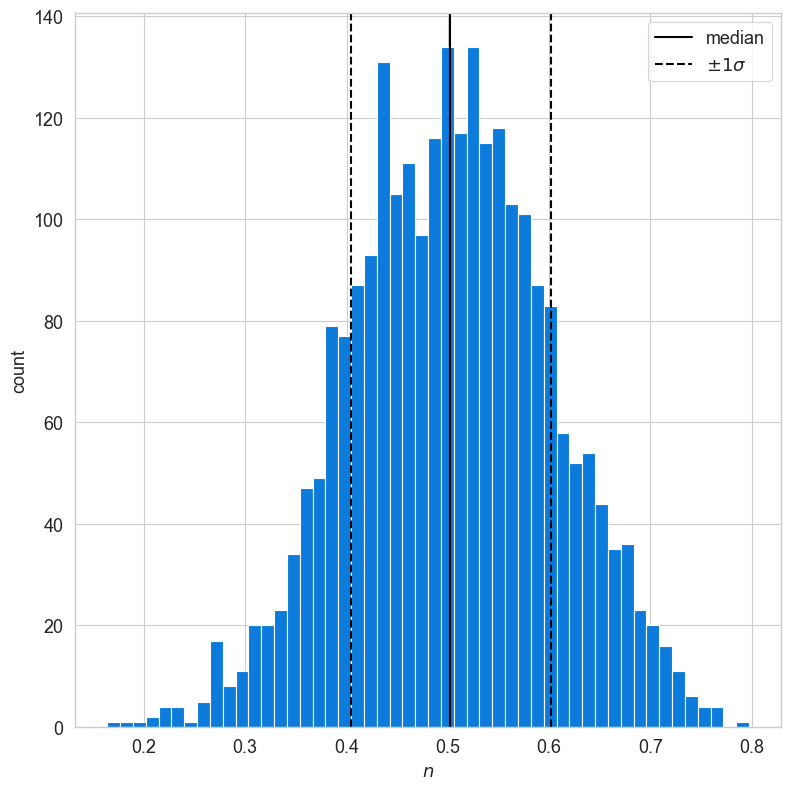

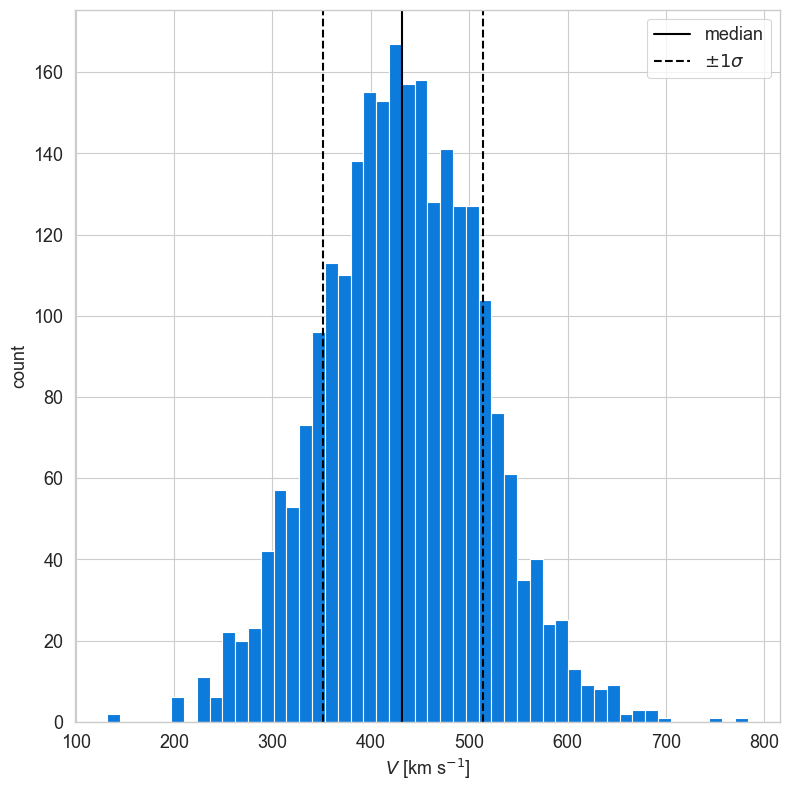

In [15]:
#plot distribution of randomized parameters V and n of Equation 1 & 2 in paper (L1)

nbin=50

ratio = ratio.reshape(-1, 1)
plt.figure(1, figsize=(8,8), dpi=100)
plt.hist(ratio, nbin, color=c3)
plt.axvline(np.median(ratio), color=c0, linestyle='-', linewidth=1.5, label='median')
plt.axvline(ratio.mean()-ratio.std(), color=c0, linestyle='--', linewidth=1.5, label=r'$\pm 1\sigma$')
plt.axvline(ratio.mean()+ratio.std(), color=c0, linestyle='--', linewidth=1.5)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.xlabel('$n$', fontsize=13)
plt.ylabel('count', fontsize=13)
plt.legend(fontsize=13)
plt.tight_layout()
#plt.savefig('ratio_hist.png')

plt.figure(3, figsize=(8,8), dpi=100)
plt.hist(V1_l1, nbin, color=c3)
plt.axvline(np.median(V1_l1), color=c0, linestyle='-', linewidth=1.5, label='median')
plt.axvline(V1_l1.mean()-V1_l1.std(), color=c0, linestyle='--', linewidth=1.5, label=r'$\pm 1\sigma$')
plt.axvline(V1_l1.mean()+V1_l1.std(), color=c0, linestyle='--', linewidth=1.5)
plt.tick_params(axis='x', labelsize=13)
plt.tick_params(axis='y', labelsize=13)
plt.xlabel('$V$ [km s$^{-1}$]', fontsize=13)
plt.ylabel('count', fontsize=13)
plt.legend(fontsize=13)
plt.tight_layout()
#plt.savefig('vel_hist.png')

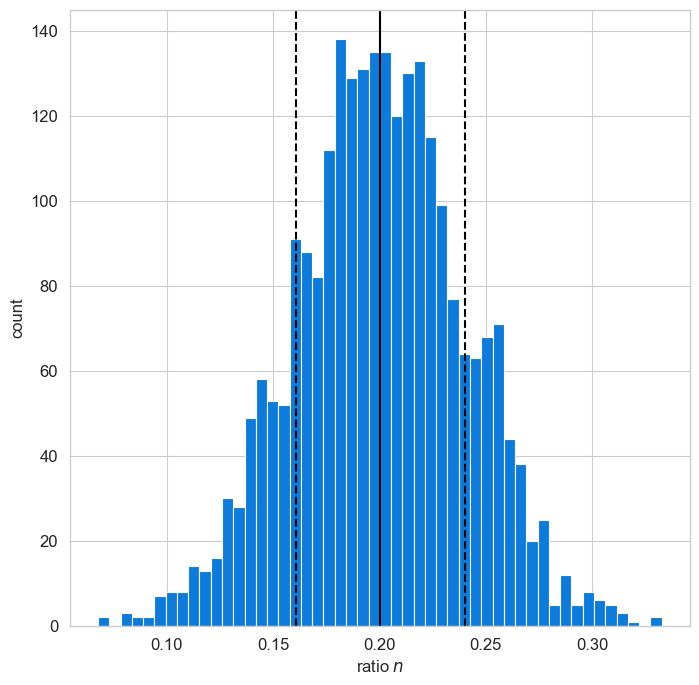

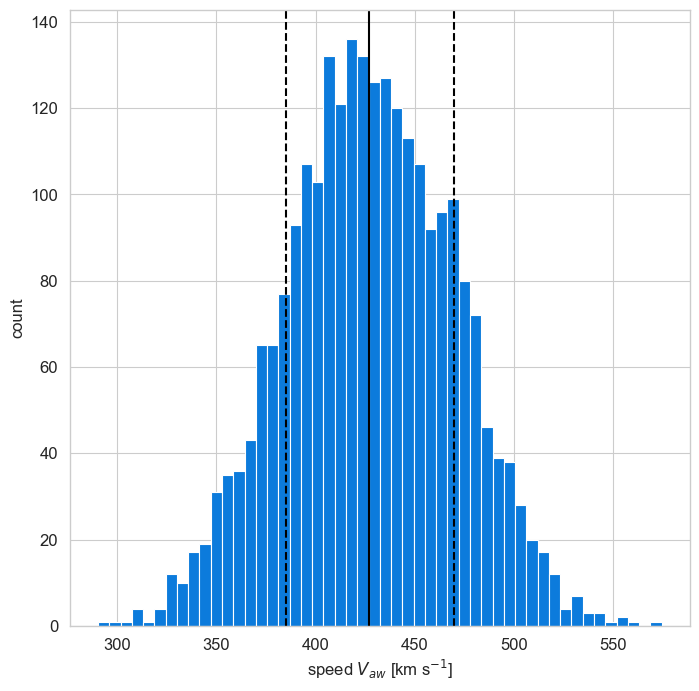

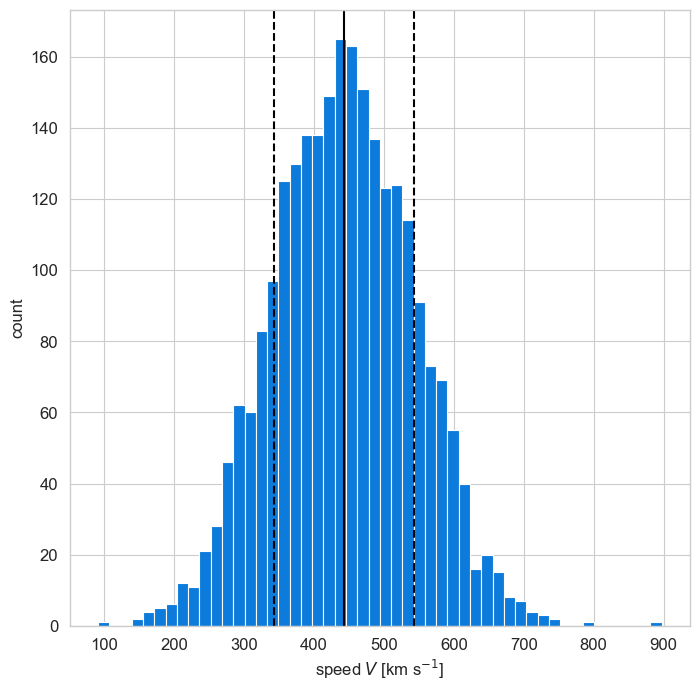

In [16]:
#plot distribution of randomized parameters V, V_aw, n, and resulting time shift (Equation 1 & 2 in paper) (STEREO-A)

nbin=50

ratio = ratio.reshape(-1, 1)
plt.figure(1, figsize=(8,8), dpi=100)
plt.hist(ratio_sc, nbin, color=c3)
plt.axvline(np.median(ratio_sc), color=c0, linestyle='-', linewidth=1.5)
plt.axvline(ratio_sc.mean()-ratio_sc.std(), color=c0, linestyle='--', linewidth=1.5)
plt.axvline(ratio_sc.mean()+ratio_sc.std(), color=c0, linestyle='--', linewidth=1.5)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.xlabel('ratio $n$', fontsize=12)
plt.ylabel('count', fontsize=12)
#plt.savefig('ratio_hist.png')

plt.figure(2, figsize=(8,8), dpi=100)
plt.hist(V_ambwind, nbin, color=c3)
plt.axvline(np.median(V_ambwind), color=c0, linestyle='-', linewidth=1.5)
plt.axvline(V_ambwind.mean()-V_ambwind.std(), color=c0, linestyle='--', linewidth=1.5)
plt.axvline(V_ambwind.mean()+V_ambwind.std(), color=c0, linestyle='--', linewidth=1.5)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.xlabel('speed $V_{aw}$ [km s$^{-1}$]', fontsize=12)
plt.ylabel('count', fontsize=12)
#plt.savefig('vel_hist.png')

plt.figure(3, figsize=(8,8), dpi=100)
plt.hist(V1_sc, nbin, color=c3)
plt.axvline(np.median(V1_sc), color=c0, linestyle='-', linewidth=1.5)
plt.axvline(V1_sc.mean()-V1_sc.std(), color=c0, linestyle='--', linewidth=1.5)
plt.axvline(V1_sc.mean()+V1_sc.std(), color=c0, linestyle='--', linewidth=1.5)
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.xlabel('speed $V$ [km s$^{-1}$]', fontsize=12)
plt.ylabel('count', fontsize=12)

if calc_time_shift:
    plt.figure(4, figsize=(8,8), dpi=100)
    plt.hist(delta_t_sc_all[0]/60./60., nbin, color=c3)
    plt.axvline(np.median(delta_t_sc_all[0])/60./60., color=c0, linestyle='-', linewidth=1.5)
    plt.axvline((delta_t_sc_all[0].mean()-delta_t_sc_all[0].std())/60./60., color=c0, linestyle='--', linewidth=1.5)
    plt.axvline((delta_t_sc_all[0].mean()+delta_t_sc_all[0].std())/60./60., color=c0, linestyle='--', linewidth=1.5)
    plt.tick_params(axis='x', labelsize=12)
    plt.tick_params(axis='y', labelsize=12)
    plt.xlabel('time shift for first data point [h]', fontsize=12)
    plt.ylabel('count', fontsize=12)

#plt.savefig('vel_hist.png')

### Load observed time shift (from 32 identified CME events) and save calculated time shift

In [17]:
import_diff_arrival = True

if import_diff_arrival:

    times = pd.read_csv(data_path+'CME_events_times_new.csv', header=0, delimiter=';')
    times.sta_start = pd.to_datetime(times.sta_start, format='%Y-%m-%dT%H:%MZ')
    times.sta_end = pd.to_datetime(times.sta_end, format='%Y-%m-%dT%H:%MZ')
    times.l1_start = pd.to_datetime(times.l1_start, format='%Y-%m-%dT%H:%MZ')
    times.l1_end = pd.to_datetime(times.l1_end, format='%Y-%m-%dT%H:%MZ')

    print('Number of identified CMEs:', len(times.l1_start))
    #arr_speed = [sc_input.vt[sc_input.time == times.sta_start[i]][0] for i in range(len(times.sta_start))]
    #print(arr_speed)
    #print(diff_arrival)#
    #print(times.sta_start.iloc[(np.where(diff_arrival==min(diff_arrival))[0][0])])
    #print(min(diff_arrival))
    #print(len(diff_arrival), len(arr_speed))

Number of identified CMEs: 32


In [18]:
if calc_time_shift:
    delta_t_mean_l1 = delta_t_l1_all.mean(1)
    delta_t_std_l1 = delta_t_l1_all.std(1)

    delta_t_mean_sc = delta_t_sc_all.mean(1)
    #delta_t_mean_sc1 = delta_t_sc_all1.mean(1)
    delta_t_std_sc = delta_t_sc_all.std(1)

    #delta_t_mean_sc_science = delta_t_sc_all_science.mean(1)
    #delta_t_std_sc_science = delta_t_sc_all_science.std(1)

In [19]:
if calc_time_shift:
    if beacon:
        if use_plasma == False:
            pickle.dump([delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc, delta_t_mean_sc, delta_t_mean_sc1, delta_t_std_sc], open(data_path+'mean_time_shift_and_sigma_beacon.p', 'wb'))
        else:
            pickle.dump([delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc, delta_t_mean_sc, delta_t_std_sc], open(data_path+'mean_time_shift_and_sigma_beacon_plasma_new.p', 'wb'))
    else: pickle.dump([delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc, delta_t_mean_sc, delta_t_mean_sc1, delta_t_std_sc], open(data_path+'mean_time_shift_and_sigma_science.p', 'wb'))
    print('done')

In [20]:
if beacon:
    print('load beacon data ..')
    if use_plasma == False:
        [delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc, delta_t_mean_sc, delta_t_mean_sc1, delta_t_std_sc] = pickle.load(open(data_path+'mean_time_shift_and_sigma_beacon.p', 'rb'))
    else:
        print('use plasma ..')
        [delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc, delta_t_mean_sc, delta_t_std_sc] = pickle.load(open(data_path+'mean_time_shift_and_sigma_beacon_plasma_new.p', 'rb'))
else: [delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc, delta_t_mean_sc, delta_t_mean_sc1, delta_t_std_sc] = pickle.load(open(data_path+'mean_time_shift_and_sigma_science.p', 'rb'))

print('done')

load beacon data ..
use plasma ..
done


### Shift L1 arrivals to Earth to get time shift between Earth and STEREO-A

In [21]:
#print(times.wind_start)
nan_mask = np.isnan(delta_t_mean_l1)

l1_shifted = []
for i in range(len(l1_input)):
    if nan_mask[i] == False:
        #print(delta_t_mean_l1[i])
        l1_shifted.append(l1_input[i].time+timedelta(seconds=delta_t_mean_l1[i].astype(float)))
    else:
        l1_shifted.append(np.nan)

#l1_shifted = [l1_input[i].time+timedelta(seconds=delta_t_mean_l1[i].astype(float)) for i in range(len(delta_t_mean_l1))]

times_earth_start = [l1_shifted[np.where(l1_input.time == i)[0][0]] for i in times.l1_start]
error_times_earth_start = np.array([delta_t_std_l1[l1_input.time==[i]][0] for i in times.l1_start])

diff_arrival = np.array([(i-j).total_seconds() for i,j in zip(times_earth_start, times.sta_start)])

diff_arrival_l1_sta = np.array([(i-j).total_seconds() for i,j in zip(times.l1_start, times.sta_start)])

#print(diff_arrival/3600)
print(diff_arrival_l1_sta/3600)


[  9.05       -15.6          6.45         2.51666667   9.75
 -20.25         2.48333333   3.           4.7          6.8
   5.75         3.01666667   4.96666667   4.71666667   3.53333333
   3.85         2.3         -0.35         4.45         1.9
   2.73333333  -1.26666667   1.45        -1.28333333   0.45
   2.78333333  -1.86666667  -0.26666667  -4.61666667  22.05
   1.83333333   2.58333333]


In [22]:
print('Difference arrival time (east, h): ', round(np.mean(diff_arrival_l1_sta[times.sta_start<datetime(2023,8,12)])/3600.,1))
print('Difference arrival time (west, h): ', round(np.mean(diff_arrival_l1_sta[times.sta_start>datetime(2023,8,12)])/3600.,1))

print('Number of events with negative lead times, L1-STEREO-A: ', len(diff_arrival_l1_sta[diff_arrival_l1_sta<0.]))
print('Number of events with negative lead times, Earth-STEREO-A (after shifting L1 arrivals to Earth): ', len(diff_arrival[diff_arrival<0.]))

Difference arrival time (east, h):  2.0
Difference arrival time (west, h):  2.2
Number of events with negative lead times, L1-STEREO-A:  8
Number of events with negative lead times, Earth-STEREO-A (after shifting L1 arrivals to Earth):  6


In [23]:
for i in range(len(diff_arrival_l1_sta)):
        print('CME event '+str(i+1)+' :', times.sta_start[i], np.round(diff_arrival_l1_sta[i]/3600,1))


CME event 1 : 2022-12-18 10:48:00 9.0
CME event 2 : 2023-01-04 12:34:00 -15.6
CME event 3 : 2023-01-17 14:36:00 6.4
CME event 4 : 2023-03-15 01:16:00 2.5
CME event 5 : 2023-03-22 21:46:00 9.8
CME event 6 : 2023-04-20 04:30:00 -20.2
CME event 7 : 2023-04-23 14:29:00 2.5
CME event 8 : 2023-05-09 19:06:00 3.0
CME event 9 : 2023-05-12 01:06:00 4.7
CME event 10 : 2023-07-14 08:36:00 6.8
CME event 11 : 2023-07-16 12:50:00 5.8
CME event 12 : 2023-07-25 18:51:00 3.0
CME event 13 : 2023-08-01 06:08:00 5.0
CME event 14 : 2023-08-04 02:09:00 4.7
CME event 15 : 2023-09-12 06:52:00 3.5
CME event 16 : 2023-09-18 09:04:00 3.8
CME event 17 : 2023-09-24 17:35:00 2.3
CME event 18 : 2023-10-20 08:25:00 -0.4
CME event 19 : 2023-11-05 03:39:00 4.4
CME event 20 : 2023-11-12 03:36:00 1.9
CME event 21 : 2023-11-30 20:50:00 2.7
CME event 22 : 2023-12-15 12:12:00 -1.3
CME event 23 : 2023-12-29 10:10:00 1.4
CME event 24 : 2024-01-03 15:37:00 -1.3
CME event 25 : 2024-02-11 00:52:00 0.4
CME event 26 : 2024-03-03 0

### Plot time shift to Earth 

1. for L1 and STEREO-A data
2. only for STEREO-A data (Figure 4 in Paper)


In [24]:
delta_r_earth = earth_pos.r-sc_input_heeq.r

index_time_shift = np.where([sc_input['time'] == i for i in times.sta_start])
#print(index_time_shift[1])

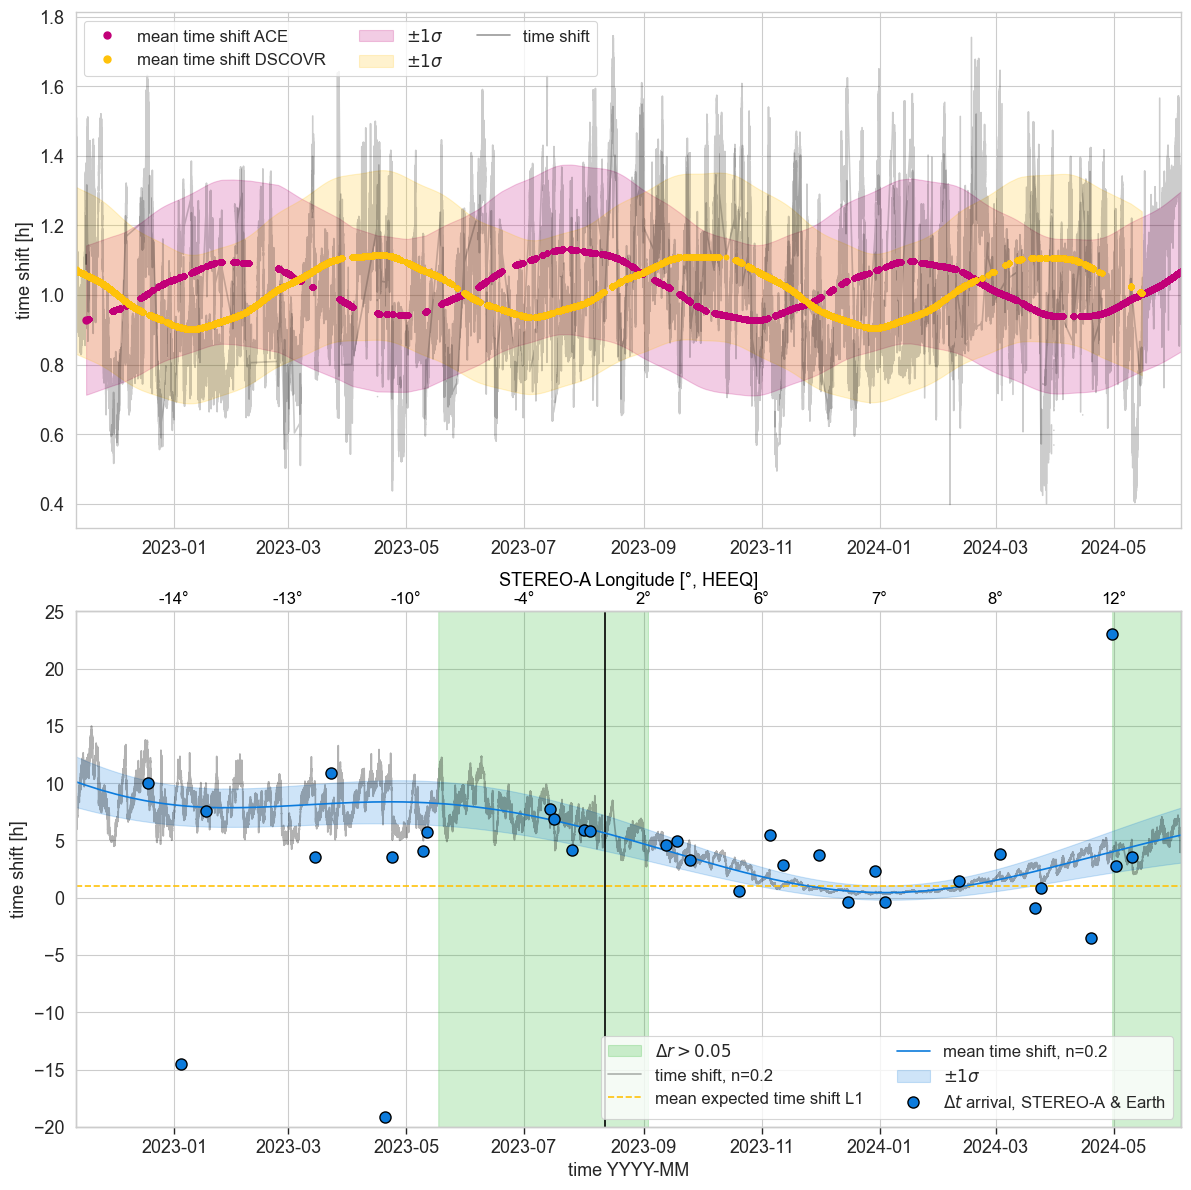

In [25]:

fig, (ax1, ax2) = plt.subplots(2, figsize=(12,12), dpi=100)

ax1.plot(l1_input.time[l1_input.sc == 1], delta_t_l1[l1_input.sc == 1]/60./60., color=c0, alpha=0.2)
ax1.plot(l1_input.time[l1_input.sc == 0], delta_t_l1[l1_input.sc == 0]/60./60., color=c0, alpha=0.2)
ax1.plot(l1_input.time[l1_input.sc == 0], delta_t_mean_l1[l1_input.sc == 0]/60./60.,color=c1, marker='o', ls=' ', ms=3 )
ax1.plot(l1_input.time[l1_input.sc == 1], delta_t_mean_l1[l1_input.sc == 1]/60./60.,color=c2, marker='o', ls=' ', ms=3 )
ax1.plot(l1_input.time[l1_input.sc == 0][0], delta_t_mean_l1[l1_input.sc == 0][0]/60./60.,color=c1, label='mean time shift ACE', marker='o', ls=' ', ms=5 )
ax1.plot(l1_input.time[l1_input.sc == 1][0], delta_t_mean_l1[l1_input.sc == 1][0]/60./60.,color=c2, label='mean time shift DSCOVR', marker='o', ls=' ', ms=5 )
ax1.fill_between(l1_input.time[l1_input.sc == 0], (delta_t_mean_l1[l1_input.sc == 0]-delta_t_std_l1[l1_input.sc == 0])/60./60.,
                 (delta_t_mean_l1[l1_input.sc == 0]+delta_t_std_l1[l1_input.sc == 0])/60./60., color=c1, alpha=0.2, label=r'$\pm 1 \sigma$')
ax1.fill_between(l1_input.time[l1_input.sc == 1], (delta_t_mean_l1[l1_input.sc == 1]-delta_t_std_l1[l1_input.sc == 1])/60./60.,
                 (delta_t_mean_l1[l1_input.sc == 1]+delta_t_std_l1[l1_input.sc == 1])/60./60., color=c2, alpha=0.2, label=r'$\pm 1 \sigma$')

ax1.plot(l1_input.time[l1_input.sc == 0][0:2], delta_t_l1[l1_input.sc == 0][0:2]/60./60., color=c0, alpha=0.4, label='time shift')

ax1.set_xlim(l1_input.time[0],l1_input.time[-1])
ax1.legend(fontsize=12, ncol=3)
ax1.tick_params(axis='x', labelsize=13)
ax1.tick_params(axis='y', labelsize=13)
ax1.set_ylabel('time shift [h]', fontsize=13)

ax2.fill_between(sc_input.time, -30, 30, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$')
ax2.plot([datetime(2023,8,12),datetime(2023,8,12)], [-45,45], 'k-')
ax2.plot(sc_input.time, delta_t_sc/60./60., color=c0, alpha=0.3, label='time shift, n=0.2')
ax2.plot([sc_input.time[0],sc_input.time[-1]], [np.nanmean(delta_t_mean_l1)/3600.,np.nanmean(delta_t_mean_l1)/3600.], color=c2, ls='--', label='mean expected time shift L1')
#ax2.plot(sc_input.time, delta_t_mean_sc1/60./60.,color=c0, alpha=0.3, ls='--', label='mean time shift, n=0.5')
ax2.plot(sc_input.time, delta_t_mean_sc/60./60.,color=c3, label='mean time shift, n=0.2')
ax2.fill_between(sc_input.time, (delta_t_mean_sc-delta_t_std_sc)/60./60., (delta_t_mean_sc+delta_t_std_sc)/60./60., color=c3, alpha=0.2,label=r'$\pm 1 \sigma$')
ax2.plot(times.sta_start, diff_arrival/60./60., 'o', ms=8, color=c3, mec='black', label=r'$\Delta t$ arrival, STEREO-A & Earth')
#ax2.errorbar(times.sta_start, diff_arrival/60./60., yerr=error_times_earth_start/60./60., marker='o', ls=' ', ms=3, color=c2, label=r'$\Delta t$ arrival, STEREO-A & Earth')
#plt.errorbar(times.sta_start, diff_arrival_l1_sta/60./60., yerr=error_times_earth_start/60./60., marker='o', alpha=0.3, ls=' ', ms=3, color=c2, label=r'$\Delta t$ arrival, STEREO-A & L1')
ax2.set_xlim(sc_input.time[0],sc_input.time[-1])
ax2.set_ylim(-20,25)
ax2.legend(loc='lower right', ncols=2, fontsize=12)
ax2.tick_params(axis='x', labelsize=13)
ax2.tick_params(axis='y', labelsize=13)
ax2.set_xlabel('time YYYY-MM', fontsize=13)
ax2.set_ylabel('time shift [h]', fontsize=13)
t_float = date2num(sc_input.time)
ax3 = ax2.twiny()
ticks = ax2.get_xticks()
ax3.set_xticks(mdates.num2date(ticks))
ax3.grid(False)
lon_interp = np.interp(ticks, t_float, sc_input_heeq.lon)
ax3.set_xticklabels([f"{L:.0f}°" for L in lon_interp], color=c0, fontsize=12)
ax3.set_xlabel('STEREO-A Longitude [°, HEEQ]', color=c0,fontsize=13)  # we already handled the x-label with ax1
ax3.tick_params(axis='x', length=0)
ax3.set_xlim(ax1.get_xlim())

plt.tight_layout()

#plt.savefig('time_shift_sta_mean_std_beacon_plasma_444.png')

### Create Figure 5 in paper

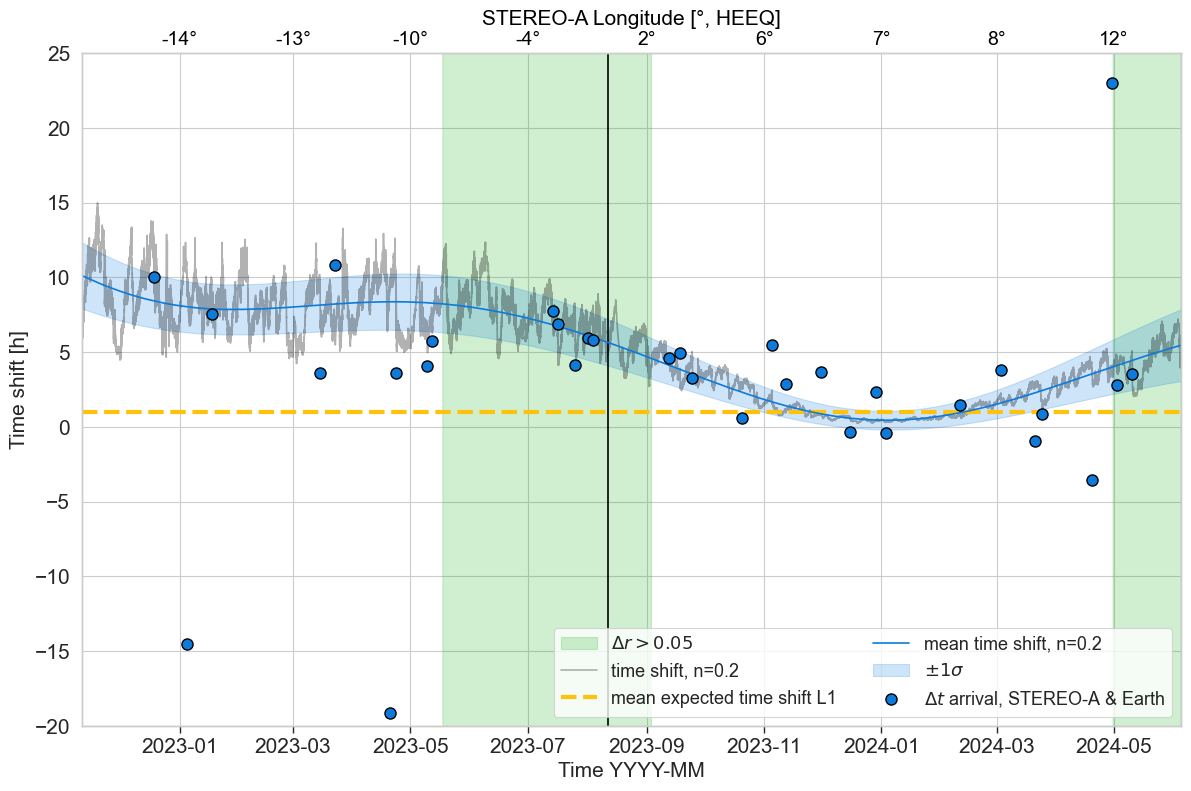

In [26]:

fig, ax2 = plt.subplots(figsize=(12,8), dpi=100)

ax2.fill_between(sc_input.time, -30, 30, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$')
ax2.plot([datetime(2023,8,12),datetime(2023,8,12)], [-45,45], 'k-')
ax2.plot(sc_input.time, delta_t_sc/60./60., color=c0, alpha=0.3, label='time shift, n=0.2')
ax2.plot([sc_input.time[0],sc_input.time[-1]], [np.nanmean(delta_t_mean_l1)/3600.,np.nanmean(delta_t_mean_l1)/3600.], color=c2, ls='--', lw=3, label='mean expected time shift L1')
ax2.plot(sc_input.time, delta_t_mean_sc/60./60.,color=c3, label='mean time shift, n=0.2')
ax2.fill_between(sc_input.time, (delta_t_mean_sc-delta_t_std_sc)/60./60., (delta_t_mean_sc+delta_t_std_sc)/60./60., color=c3, alpha=0.2,label=r'$\pm 1 \sigma$')
ax2.plot(times.sta_start, diff_arrival/60./60., 'o', ms=8, color=c3, mec='black', label=r'$\Delta t$ arrival, STEREO-A & Earth')
#ax2.errorbar(times.sta_start, diff_arrival/60./60., yerr=error_times_earth_start/60./60., marker='o', ls=' ', ms=3, color=c2, label=r'$\Delta t$ arrival, STEREO-A & Earth')
#plt.errorbar(times.sta_start, diff_arrival_l1_sta/60./60., yerr=error_times_earth_start/60./60., marker='o', alpha=0.3, ls=' ', ms=3, color=c2, label=r'$\Delta t$ arrival, STEREO-A & L1')
ax2.set_xlim(sc_input.time[0],sc_input.time[-1])
ax2.set_ylim(-20,25)
ax2.legend(loc='lower right', ncols=2, fontsize=13)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)
ax2.set_xlabel('Time YYYY-MM', fontsize=15)
ax2.set_ylabel('Time shift [h]', fontsize=15)
t_float = date2num(sc_input.time)
ax3 = ax2.twiny()
ticks = ax2.get_xticks()
ax3.set_xticks(mdates.num2date(ticks))
ax3.grid(False)
lon_interp = np.interp(ticks, t_float, sc_input_heeq.lon)
ax3.set_xticklabels([f"{L:.0f}°" for L in lon_interp], color=c0, fontsize=14)
ax3.set_xlabel('STEREO-A Longitude [°, HEEQ]', color=c0,fontsize=15)  # we already handled the x-label with ax1
ax3.tick_params(axis='x', length=0)
ax3.set_xlim(ax1.get_xlim())

plt.tight_layout()

#plt.savefig('time_shift_sta_mean_std_beacon_plasma_444_sta.png')

### Find best value for parameter n in Equ. 2 
Minimizing MAE between observed and calculated time shifts, excluding 2 outliers on the east side and one outlier on the west side.

In [26]:
#delta_t_event = [delta_t[sc_input.time==[i]][0] for i in times.sta_start]
index_all = np.where([times.sta_start==i for i in sc_input.time])[0]
delta_t_mean_index = delta_t_mean_sc[index_all]
diff = np.abs((diff_arrival-delta_t_mean_index)/60./60.)
#print(diff)
sta_times_new = (times.sta_start[diff<=19.])
diff_arrival_new = diff_arrival[diff<=19.]
print(sta_times_new)
index = np.where([sta_times_new==i for i in sc_input.time])[0]
#print(index)
#print(len(index))
#print(delta_t_mean_sc[index])

0    2022-12-18 10:48:00
2    2023-01-17 14:36:00
3    2023-03-15 01:16:00
4    2023-03-22 21:46:00
6    2023-04-23 14:29:00
7    2023-05-09 19:06:00
8    2023-05-12 01:06:00
9    2023-07-14 08:36:00
10   2023-07-16 12:50:00
11   2023-07-25 18:51:00
12   2023-08-01 06:08:00
13   2023-08-04 02:09:00
14   2023-09-12 06:52:00
15   2023-09-18 09:04:00
16   2023-09-24 17:35:00
17   2023-10-20 08:25:00
18   2023-11-05 03:39:00
19   2023-11-12 03:36:00
20   2023-11-30 20:50:00
21   2023-12-15 12:12:00
22   2023-12-29 10:10:00
23   2024-01-03 15:37:00
24   2024-02-11 00:52:00
25   2024-03-03 06:00:00
26   2024-03-21 04:16:00
27   2024-03-24 14:23:00
28   2024-04-19 09:30:00
30   2024-05-02 11:26:00
31   2024-05-10 14:03:00
Name: sta_start, dtype: datetime64[ns]


In [27]:
ratio=0.5*np.ones(len(index_all))
V=421.*np.ones(len(index_all))
V_ambwind = 428.*np.ones(len(index_all))
Vearth = 30.*np.ones(len(index_all))
W = np.tan(ratio*np.arctan(V_ambwind/V))
delta_t = ((sc_input.x[index_all]/V) * ((1 + ((sc_input.y[index_all]*W)/sc_input.x[index_all])) / (1 - (Vearth*W/V))))/60.

print((np.mean(delta_t - diff_arrival)/3600.))

-3.066944005577881


In [28]:
def minimise_MAE_time_shift(x, index_in=index, real_shift=diff_arrival_new/60.):
    
    #sc = copy.deepcopy(sc_in)
    
    ratio=x[0]*np.ones(len(index_in))
    V=444.*np.ones(len(index_in))
    V_ambwind = 428.*np.ones(len(index_in))
    Vearth = 30.*np.ones(len(index_in))
    #W = np.tan(ratio*np.arctan(V/V_ambwind))
    W = np.tan(ratio*np.arctan(V/V_ambwind))

    X = sc_input.x[index_in]
    Y = sc_input.y[index_in]
      
    delta_t = ((X/V) * ((1 + ((Y*W)/X)) / (1 - (Vearth*W/V))))/60.
    #print(delta_t[0])
    
    absError = np.abs(real_shift - delta_t)
    mae = absError.mean()**0.5
    #print('MAE:', mae)
    
    return mae

In [29]:
optimise=True 

if optimise:
    
    x0=0.3
    params_opt = minimize(minimise_MAE_time_shift, x0, bounds=[(0.1, 0.5)])

    print('Optimization message: ', params_opt.message)

    parameter = params_opt.x[0]
    print('Optimized Parameters [speed CME, speed ambient wind, ratio]: ', parameter)


Optimization message:  CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Optimized Parameters [speed CME, speed ambient wind, ratio]:  0.197625051095117


### Plot Figures 2 & 3 in Paper and calculate some statistics for these plots

In [30]:
speed_range = np.arange(300, 900, 10)
#print(speed_range)
dist_range = np.arange(0.01, 0.051, 0.001)
print(dist_range)

list_exp_shift = np.zeros([len(speed_range),len(dist_range)])
list_exp_shift = [(dist_range*u.au.to(u.km)/i)/3600. for i in speed_range]

[0.01  0.011 0.012 0.013 0.014 0.015 0.016 0.017 0.018 0.019 0.02  0.021
 0.022 0.023 0.024 0.025 0.026 0.027 0.028 0.029 0.03  0.031 0.032 0.033
 0.034 0.035 0.036 0.037 0.038 0.039 0.04  0.041 0.042 0.043 0.044 0.045
 0.046 0.047 0.048 0.049 0.05 ]


In [31]:
list_exp_shift_tr = np.transpose(list_exp_shift)

speed_shock = []
sta_lon = []
for i in range(len(times.sta_start)):
    index = np.where(sc_input.time==times.sta_start[i])[0][0]
    index_heeq = np.where(sc_input_heeq.time==times.sta_start[i])[0][0]

    speed_shock.append(np.nanmean(sc_input.vt[index:index+30]))
    sta_lon.append(np.nanmean(sc_input_heeq.lon[index:index+30]))

#print(len(speed_shock))
print('Mean arrival speed of all 32 CME events: ', np.round(np.mean(speed_shock),0))
print('Std of arrival speed: ', np.round(np.std(speed_shock),0))

Mean arrival speed of all 32 CME events:  444.0
Std of arrival speed:  101.0


In [32]:
exp_time_shift = delta_t_mean_sc[index_time_shift[1]]/3600.
#exp_time_shift1 = delta_t_mean_sc1[index_time_shift[1]]/3600.
print(np.sqrt(1/len(exp_time_shift)*np.sum((exp_time_shift-diff_arrival/3600.)**2)))
#print(np.sqrt(1/len(exp_time_shift1)*np.sum((exp_time_shift1-diff_arrival/3600.)**2)))


#print(np.mean((exp_time_shift-diff_arrival/3600.)))
#print(delta_t_std_l1[0]/60)
#print(np.nanmean(delta_t_mean_l1)/3600.)
#print(np.nanmean(sc_input.vt))

7.5343533282688675


In [33]:
r=[sc_input_heeq.r[sc_input_heeq.time==[i]][0] for i in times.sta_start]
theta=[sc_input_heeq.lon[sc_input_heeq.time==[i]][0] for i in times.sta_start]

diff_arrival_hours = np.array([(i-j).total_seconds()/3600 for i,j in zip(times.l1_start, times.sta_start)])
print(diff_arrival_hours)

[  9.05       -15.6          6.45         2.51666667   9.75
 -20.25         2.48333333   3.           4.7          6.8
   5.75         3.01666667   4.96666667   4.71666667   3.53333333
   3.85         2.3         -0.35         4.45         1.9
   2.73333333  -1.26666667   1.45        -1.28333333   0.45
   2.78333333  -1.86666667  -0.26666667  -4.61666667  22.05
   1.83333333   2.58333333]


In [34]:
delta_r_l1 = l1_input_heeq.r-sc_input_heeq.r
r_dist_l1=[delta_r_l1[sc_input_heeq.time==[i]][0] for i in times.sta_start]

In [35]:
neg_lead_time = np.zeros(len(diff_arrival_hours))
neg_lead_time[diff_arrival_hours<0.] = 1.
print(np.sum(neg_lead_time))

print(diff_arrival_hours, neg_lead_time)

8.0
[  9.05       -15.6          6.45         2.51666667   9.75
 -20.25         2.48333333   3.           4.7          6.8
   5.75         3.01666667   4.96666667   4.71666667   3.53333333
   3.85         2.3         -0.35         4.45         1.9
   2.73333333  -1.26666667   1.45        -1.28333333   0.45
   2.78333333  -1.86666667  -0.26666667  -4.61666667  22.05
   1.83333333   2.58333333] [0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1.
 0. 0. 1. 1. 1. 0. 0. 0.]


In [36]:
print(np.mean(l1_input_heeq.lon[l1_input_heeq.sc==0.]))
theta_ace_all = l1_input_heeq[l1_input_heeq.sc==0.]
theta_dscovr_all = l1_input_heeq[l1_input_heeq.sc==1.]

theta_ace = np.deg2rad(theta_ace_all.lon[theta_ace_all.time==datetime(2023,8,12,12,0)])
r_ace = theta_ace_all.r[theta_ace_all.time==datetime(2023,8,12,12,0)]

theta_dscovr = np.deg2rad(theta_dscovr_all.lon[theta_dscovr_all.time==datetime(2023,8,12,12,0)])
r_dscovr = theta_dscovr_all.r[theta_dscovr_all.time==datetime(2023,8,12,12,0)]

#r_ace = np.mean(l1_input_heeq.r[l1_input_heeq.sc==0.])
#r_dscovr = np.mean(l1_input_heeq.r[l1_input_heeq.sc==1.])
theta_earth = np.deg2rad(earth_pos.lon[earth_pos.time==datetime(2023,8,12,12,0)])
r_earth = earth_pos.r[earth_pos.time==datetime(2023,8,12,12,0)]


0.005226551114216807


32


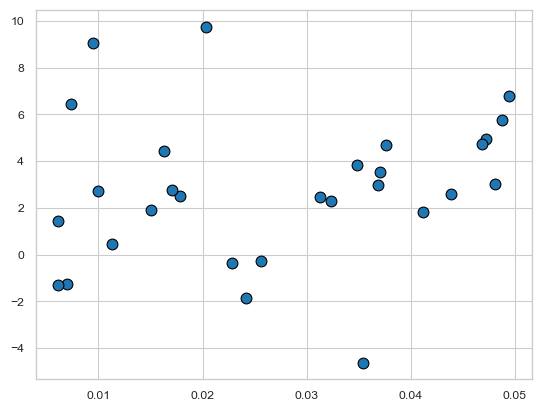

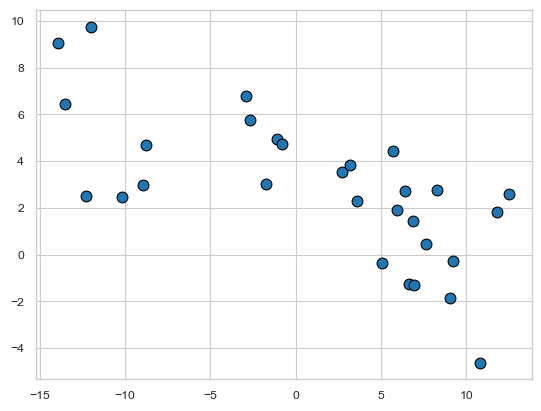

In [38]:
#plot Figures 2a and 2d in paper without outliers 

diff_arr_10 = diff_arrival_l1_sta[abs(diff_arrival_l1_sta)<36000.]
index_diff_arr_10 = np.array(np.abs(diff_arrival_l1_sta) < 36000.)
r_dist_l1_array = np.array(r_dist_l1)
print(len(index_diff_arr_10))
#print(r_dist_l1[index_diff_arr_10])
diff_arr_10_r = r_dist_l1_array[index_diff_arr_10]
theta_array = np.array(theta)
diff_arr_10_lon = theta_array[index_diff_arr_10]


plt.figure(1)
plt.scatter(diff_arr_10_r, diff_arr_10/3600., s=60, edgecolors='black')
plt.figure(2)
plt.scatter(diff_arr_10_lon, diff_arr_10/3600., s=60, edgecolors='black')

In [39]:
#print Pearson correlation with and without outliers

print('Pearson, lead-time & deltaR: ', scipy.stats.pearsonr(diff_arrival_l1_sta,r_dist_l1))
print('Pearson, lead-time & deltaLON: ', scipy.stats.pearsonr(diff_arrival_l1_sta,theta))

print('Pearson, lead-time & deltaR, within +/-10h: ', scipy.stats.pearsonr(diff_arr_10,diff_arr_10_r))
print('Pearson, lead-time & deltaLON, within +/-10h: ', scipy.stats.pearsonr(diff_arr_10,diff_arr_10_lon))

Pearson, lead-time & deltaR:  PearsonRResult(statistic=0.24234007829101084, pvalue=0.18143097600332558)
Pearson, lead-time & deltaLON:  PearsonRResult(statistic=0.11494489555628695, pvalue=0.5310273898135)
Pearson, lead-time & deltaR, within +/-10h:  PearsonRResult(statistic=0.1712990288912511, pvalue=0.3742776309366674)
Pearson, lead-time & deltaLON, within +/-10h:  PearsonRResult(statistic=-0.696413317720552, pvalue=2.7172607549456413e-05)


In [40]:
sorted_r = np.sort(r_dist_l1)
index_sorted_r = np.argsort(r_dist_l1)
sorted_arr = diff_arrival_l1_sta[index_sorted_r]

#for i,j in zip(sorted_r, sorted_arr):
 #   print(i, np.round(j/3600.,1))


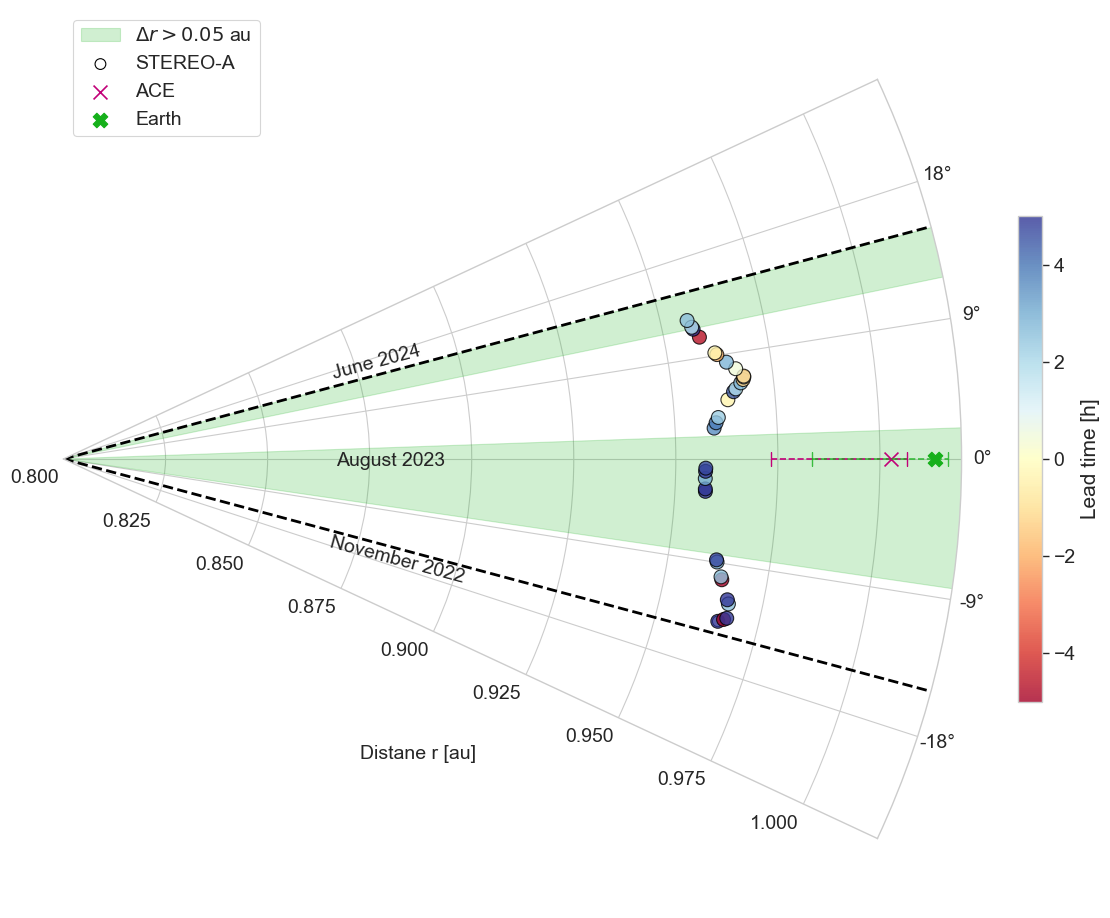

In [42]:
import matplotlib.colors as mcolors

norm_new = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=5)
norm_new1 = TwoSlopeNorm(vmin=400, vcenter=525, vmax=650)
norm_new2 = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
#norm_speed = TwoSlopeNorm(vmin=350, vcenter=450, vmax=650)

theta_line = np.deg2rad(15)  # 15 degrees in radians
r_line = np.linspace(0, 1.1, 100)  # From 0 to 1.1

# Define the colors
colors = ["#FFC20A", "#FFFFFF", "#0C7BDC"]

# Create the colormap
blue_yellow_cmap = mcolors.LinearSegmentedColormap.from_list(
    "blue_yellow_cb", colors)


#mask_r = delta_r >= 0.04

#theta_masked = np.deg2rad(sc_input_heeq.lon[mask_r])   # angular coordinate
#r_masked = sc_input_heeq.r[mask_r]                     # radial coordinate

# Build polygon: go out along mask, then back in along baseline
#theta_poly = np.concatenate([theta_masked, theta_masked[::-1]])
#print(np.rad2deg(theta_poly))
#r_poly = np.concatenate([np.full_like(r_masked, 1.1), np.full_like(r_masked, 0.8)])  # baseline at r=0.8



fig = plt.figure(figsize=(12,10))
ax = plt.subplot2grid((3,3), (0, 0), rowspan=3, colspan=3, projection='polar')
ax.fill_between(np.deg2rad(sc_input_heeq.lon),0.8,1.1, where=delta_r_earth>=0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$ au')
#ax.fill_between(np.deg2rad(sc_input_heeq.lon[0:1]),0.8,1.1, color=c4, alpha=0.2, )
ax.scatter(np.deg2rad(theta[0]), r[0], s=60, edgecolors='black', facecolors='none', label='STEREO-A')
sc=ax.scatter(np.deg2rad(theta), r, c=diff_arrival_hours, s=100, alpha=0.8, cmap='RdYlBu', norm=norm_new, edgecolors='black')
ax.plot([theta_line]*len(r_line), r_line, color='black', linestyle='--', linewidth=2)
ax.plot([-theta_line]*len(r_line), r_line, color='black', linestyle='--', linewidth=2)
#ax.scatter(np.deg2rad(theta_l1[sc_l1 == 1.0]), r_l1[sc_l1 == 1.0], c=c2, marker='x', s=40, edgecolors='black', label='DSCOVR')
#ax.scatter(np.deg2rad(theta_l1[sc_l1 == 0.0]), r_l1[sc_l1 == 0.0], c=c1, marker='x', s=40, edgecolors='black', label='ACE')
#ax.scatter(np.deg2rad(theta_l1[sc_l1 == 0.0]), r_l1[sc_l1 == 0.0], c=c1, marker='x', s=40, edgecolors='black', label='ACE')
ax.plot([0,0], [np.nanmin(l1_input_heeq.r[l1_input_heeq.sc==0.]), np.nanmax(l1_input_heeq.r[l1_input_heeq.sc==0.])], c=c1, ls='--', lw=1.2)
ax.plot([0,0], [np.nanmin(l1_input_heeq.r[l1_input_heeq.sc==0.]), np.nanmax(l1_input_heeq.r[l1_input_heeq.sc==0.])], c=c1, ls='', marker='|', ms=10)
#ax.plot([0,0], [np.nanmin(l1_input_heeq.r[l1_input_heeq.sc==1.]), np.nanmax(l1_input_heeq.r[l1_input_heeq.sc==1.])], c=c2, ls='--', lw=1.2)
ax.plot([0,0], [np.min(earth_pos.r),np.max(earth_pos.r)], c=c4, ls='--', alpha=0.8, lw=1.2)
ax.plot([0,0], [np.min(earth_pos.r),np.max(earth_pos.r)], c=c4, ls='', marker='|', ms=10, alpha=0.8)
#ax.scatter(theta_dscovr, r_dscovr, marker='x', c=c2, s=60, label='DSCOVR')
ax.scatter(theta_ace, r_ace, marker='x', c=c1, s=100, label='ACE')
ax.scatter(theta_earth, r_earth, marker='X', c=c4, s=110, label='Earth')
ax.set_rlim(0.8,1.02)
ax.set_thetamin(-25)
ax.set_thetamax(25)
ax.tick_params(axis='both', labelsize=14)
#ax.set_xlabel('Heliocentric distance [AU]', fontsize=16)
#ax.set_ylabel('Longitude [deg]', fontsize=16)
cbar=fig.colorbar(sc, ax=ax, orientation='vertical', shrink=0.5)
cbar.set_label('Lead time [h]', fontsize=15)  # Label for the colorbar
cbar.ax.tick_params(labelsize=14)  # Increase tick font size
ax.legend(loc='upper left', fontsize=14)
plt.figtext(0.3, 0.2, 'Distane r [au]', fontsize=14)
plt.figtext(0.28, 0.493, 'August 2023', fontsize=14)
plt.figtext(0.273, 0.376, 'November 2022', fontsize=14, rotation=-15)
plt.figtext(0.275, 0.58, 'June 2024', fontsize=14, rotation=15)
plt.tight_layout()
#plt.savefig('sta_l1_events.pdf')


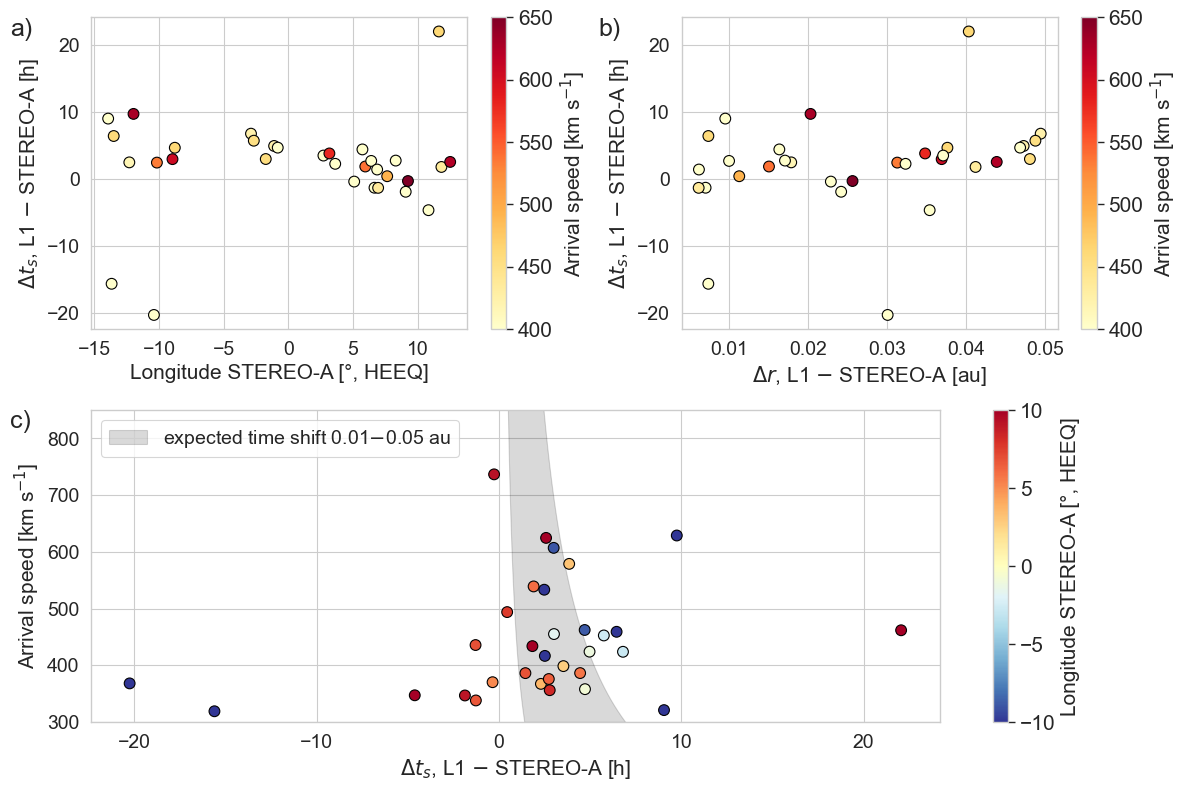

In [43]:
fig1,axes = plt.subplots(figsize=(12,8))
ax1 = plt.subplot2grid((2,2), (0, 1))
im1 = ax1.scatter(r_dist_l1, diff_arrival_l1_sta/3600., s=60, c=speed_shock, cmap='YlOrRd', norm=norm_new1, edgecolors='black')
#cbar3=fig.colorbar(sc3, orientation='vertical', shrink=1)
#cbar3.ax.tick_params(labelsize=13)
#cbar3.set_label(r'arrival speed [km s$^{-1}$]', fontsize=16)  # Label for the colorbar
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_xlabel(r'$\Delta r$, L1 $-$ STEREO-A [au]', fontsize=15)
ax1.set_ylabel(r'$\Delta t_s$, L1 $-$ STEREO-A [h]', fontsize=15)
cbar3 = fig1.colorbar(im1, ax=ax1, orientation='vertical')
cbar3.ax.tick_params(labelsize=15)
cbar3.set_label(r'Arrival speed [km s$^{-1}$]', fontsize=15)

ax3 = plt.subplot2grid((2,2), (0, 0))
im2 = ax3.scatter(theta, diff_arrival_l1_sta/3600., s=60, c=speed_shock, cmap='YlOrRd', norm=norm_new1, edgecolors='black')
#cbar4.set_label(r'arrival speed [km s$^{-1}$]', fontsize=16)  # Label for the colorbar
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)
#axes[1].set_yticklabels([])
ax3.set_xlabel(r'Longitude STEREO-A [°, HEEQ]', fontsize=15)
ax3.set_ylabel(r'$\Delta t_s$, L1 $-$ STEREO-A [h]', fontsize=15)
cbar4 = fig1.colorbar(im2, ax=ax3, orientation='vertical')
cbar4.ax.tick_params(labelsize=15)
cbar4.set_label(r'Arrival speed [km s$^{-1}$]', fontsize=15)

ax2 = plt.subplot2grid((2,2), (1, 0), colspan=2)
ax2.fill_betweenx(speed_range, list_exp_shift_tr[0], list_exp_shift_tr[-1], color=c0, alpha=0.15, label='expected time shift 0.01$-$0.05 au')
sc2 = plt.scatter(diff_arrival_l1_sta/3600., speed_shock, c=sta_lon, s=60, cmap='RdYlBu_r', norm=norm_new2, edgecolors='black')
cbar2=fig.colorbar(sc2, orientation='vertical')
cbar2.ax.tick_params(labelsize=15)
cbar2.set_label('Longitude STEREO-A [°, HEEQ]', fontsize=15)  # Label for the colorbar
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_xlabel(r'$\Delta t_s$, L1 $-$ STEREO-A [h]', fontsize=15)
ax2.set_ylabel(r'Arrival speed [km s$^{-1}$]', fontsize=15)
ax2.set_ylim(300,850)
ax2.legend(fontsize=14, loc='upper left')
#fig.subplots_adjust(hspace=0)
plt.figtext(0.01, 0.95, 'a)', fontsize=18)
plt.figtext(0.5, 0.95, 'b)', fontsize=18)
plt.figtext(0.01, 0.46, 'c)', fontsize=18)
plt.tight_layout()
#fig1.subplots_adjust(left=0.94, right=0.95, hspace=0.75)

In [59]:
#for paper:
#for i in range(len(diff_arrival_l1_sta)):
 #   print(np.round(theta[i],1), np.round(diff_arrival_l1_sta[i]/3600.,1))

### Calculate SYM-H using the Temerin & Li model for L1 and STEREO-A data

In [60]:
def interp_nans(sc_in):
    sc = copy.deepcopy(sc_in)
    
    keys_to_interp = [name for name in sc.dtype.names if name != 'time']
    
    n = len(sc)

    # Use index positions as the x-axis (since time steps are regular)
    x = np.arange(n)

    for key in keys_to_interp:
        y = sc[key]

        if y.dtype.kind in 'f':  # Only interpolate float fields
            mask = ~np.isnan(y)

            if np.sum(mask) >= 2:  # Need at least 2 points to interpolate
                # Interpolate over valid points
                sc[key] = np.interp(x, x[mask], y[mask])
            else:
                print(f"Skipping '{key}': not enough valid data to interpolate.")
                
    return sc

    
def interp_to_time(sc_in, time_shift_seconds, res=1):

    #if iterative:
        
        #define time grid here so that it is the same for all.
        #use more than just sigma uncertainty but rather all ensembles for binned data.
        #and then use the same ensemble size for SYM-H prediction and calculate error as for INGRID event.
        #ask Chris if this strategy is legit.
            
        #if sc_name == 'Wind':

         #   sc = copy.deepcopy(sc_in)
          #  sc.time = sc_in.time+np.array(time_shift_seconds, dtype='timedelta64[s]')
           # 
            #t_start=(sc_in.time[0]+np.array(time_shift_seconds[0], dtype='timedelta64[s]')).astype(datetime)
            #t_end=(sc_in.time[-1]+np.array(time_shift_seconds[0], dtype='timedelta64[s]')).astype(datetime)

        #else:
    sc = copy.deepcopy(sc_in)
    
    nan_mask = np.isnan(time_shift_seconds)
    
    for i in range(len(sc_in)):
        if nan_mask[i] == False:
        #print(delta_t_mean_l1[i])
            sc.time[i] = sc_in[i].time+timedelta(seconds=time_shift_seconds[i].astype(float))
        else:
            sc.time[i] = np.nan
    
    #sc.time = [sc_in.time[i]+timedelta(seconds=time_shift_seconds[i].astype(float)) for i in range(len(sc_in.time))]
    print(sc.time[0])
    print(sc.time[-1])
    #t_start=sc.time[0]
    #t_end=sc.time[-1]

    t_start=sc_in.time[0]+timedelta(seconds=time_shift_seconds[0].astype(float))
    t_end=sc_in.time[-1]+timedelta(seconds=time_shift_seconds[0].astype(float))#datetime(2024,6,5)#sc.time[-1].astype(datetime)

    #print(t_start)

    t1=sc.time

    format_str = '%Y-%m-%d %H:%M'  
    t0 = datetime.strptime(datetime.strftime(t_start, format_str), format_str) #+timedelta(minutes=1)

    time_all = [ t0 + timedelta(minutes=res*n) for n in range(int ((t_end - t_start).days*(60./res)*24)+1)]
    time_mat=mdates.date2num(time_all) 

    sc_rec=np.zeros(np.size(time_all),dtype=[('time',object), ('time_err', float),
                                             ('bx', float),('by', float),('bz', float),('bt', float),\
                                             ('r', float),('lat', float),('lon', float),\
                                             ('x', float),('y', float),('z', float),('vx', float),\
                                             ('vy', float),('vz', float),('vt', float),('np', float),\
                                             ('symh', float), ('symh_err', float) ] ) 
    #('tp', float),

    sc_rec=sc_rec.view(np.recarray) 
    
    time_m_num = []
    for i in range(len(sc_in)):
        if nan_mask[i] == False:
            time_m_num.append(mdates.date2num(t1[i])) #make date number
        else:
            time_m_num.append(np.nan)

    sc_rec.time=time_all

    sc_rec.time_err=np.zeros(len(time_all))

    sc_rec.np=np.interp(time_mat, time_m_num, sc.np)
    #sc_rec.tp=np.interp(time_mat, time_m_num, sc.tp) 
    sc_rec.vt=np.interp(time_mat, time_m_num, sc.vt)

    sc_rec.bx=np.interp(time_mat, time_m_num, sc.bx)
    sc_rec.by=np.interp(time_mat, time_m_num, sc.by)
    sc_rec.bz=np.interp(time_mat, time_m_num, sc.bz)
    sc_rec.bt=np.interp(time_mat, time_m_num, sc.bt)

    sc_rec.x=np.interp(time_mat, time_m_num, sc.x)
    sc_rec.y=np.interp(time_mat, time_m_num, sc.y)
    sc_rec.z=np.interp(time_mat, time_m_num, sc.z)

    sc_rec.symh=np.zeros(len(time_all))
    sc_rec.symh_err=np.zeros(len(time_all))

    sc_rec.r=np.interp(time_mat, time_m_num, sc.r)
    sc_rec.lon=np.interp(time_mat, time_m_num, sc.lon)
    sc_rec.lat=np.interp(time_mat, time_m_num, sc.lat)

    rec_all = interp_nans(sc_rec) 

    return rec_all

In [61]:
calc_l1_symh = False


if calc_l1_symh:
    start_time = time.time()

    #time_shift_wind_mean = np.mean(delta_t_wind_all,axis=1)
    #time_shift_wind_std = np.std(delta_t_wind_all,axis=1)

    #random_time_wind = np.transpose([time_shift_wind_mean, time_shift_wind_mean-time_shift_wind_std, time_shift_wind_mean+time_shift_wind_std])

    wind_generator = interp_to_time(l1_input, delta_t_mean_l1, res=1)
    #print(wind_generator)

    #for rec in wind_generator:
    wind_generator.symh = pred.calc_dst_temerin_li(mdates.date2num(wind_generator.time), wind_generator.bt, wind_generator.bx, 
                                                   wind_generator.by, wind_generator.bz, wind_generator.vt, wind_generator.vt, 
                                                   wind_generator.np, dst1=-10, dst2=-6, dst3=-8, version='2006', linear_t_correction=True, minute_res=True)



    print('Done in: ',np.round((time.time()-start_time)), 'seconds')

In [62]:
if calc_l1_symh:
    pickle.dump(wind_generator, open(data_path+'l1_symh_fin.p', 'wb'))

In [64]:
interp_sta = True

if interp_sta:
    
    start_time = time.time()

    sc_generator = interp_to_time(sc_input, delta_t_mean_sc)

    print('Done in: ',np.round((time.time()-start_time)), 'seconds')

2022-11-11 10:08:07.902344
2024-06-05 05:28:21.820312
Done in:  21.0 seconds


In [65]:
sc_generator.time_err = delta_t_std_sc/3600.
print(sc_generator.time_err)
print(len(sc_generator.time), len(sc_input.time), len(delta_t_std_sc))

print(sc_input.time[0], sc_generator.time[0])
print(sc_input.time[-1], sc_generator.time[-1])

[2.20839334 2.20838332 2.20837307 ... 2.40435028 2.40436149 2.40437245]
823681 823681 823681
2022-11-11 00:00:00 2022-11-11 10:08:00
2024-06-05 00:00:00 2024-06-05 10:08:00


In [44]:
mean_err_time_shift = np.nanmean(delta_t_std_sc)/3600/24
print(mean_err_time_shift)

#plt.figure(1, figsize=(8,4))
#plt.plot(sc_input.time, delta_t_std_sc/3600)

0.060864596896701394


In [67]:
calc_symh = False
mean_density = np.nanmean(sc_input.np)

if calc_symh: 
    def create_bins(lower_bound, width, quantity):
        bins = []
        for low in range(lower_bound, lower_bound + quantity * width + 1, width):
            bins.append((low, low + width))
        return bins

    # Constants
    n_ensembles = 1000
    days = 3
    pre_window_minutes = days*24*60 # 3 days * 24 hours * 60 minutes
    width_days = 10
    window_minutes = width_days*24*60
    bins = create_bins(lower_bound=pre_window_minutes, width=window_minutes, quantity=int(len(sc_generator.time)/window_minutes))

    sc_gen_all = []
    symh_ensemble_all = []

    start = time.time()
    for i, (bin_start, bin_end) in enumerate(bins):
    #for i in range(0,1):
        print(f"Processing bin {i}...")

        # Include 3 days before bin start
        start_index = bin_start - pre_window_minutes if bin_start - pre_window_minutes > 0 else 0
        sc_gen = sc_generator[start_index:bin_end+1]
        #err_delta_t = delta_t_std_sc[start_index:bin_end+1]

        #print(sc_gen.time[0], sc_gen.time[-1])

        # Simulate variables
        dst1 = np.abs(np.random.normal(10, 2, n_ensembles))
        dst2 = np.abs(np.random.normal(6, 1, n_ensembles))
        dst3 = np.abs(np.random.normal(10, 2, n_ensembles))

        def simulate_noise(arr, scale):
            return np.transpose([np.random.normal(k, np.abs(scale * k), n_ensembles) for k in arr])

        factor = 0.16

        random_time = np.random.normal(0, mean_err_time_shift, n_ensembles)

        bt = np.abs(simulate_noise(sc_gen.bt, factor))
        bx = simulate_noise(sc_gen.bx, (1 / np.sqrt(3) * factor))
        by = simulate_noise(sc_gen.by, (1 / np.sqrt(3) * factor))
        bz = simulate_noise(sc_gen.bz, (1 / np.sqrt(3) * factor))
        speed = simulate_noise(sc_gen.vt, 0.05)
        density = simulate_noise(sc_gen.np, 0.28)
        density[density<=0.] = mean_density

        # Ensemble calculation
        symh_list_ensemble = []
        for n in range(n_ensembles):
            symh_ensemble = pred.calc_dst_temerin_li(
                mdates.date2num(sc_gen.time)+random_time[n], bt[n], bx[n], by[n], bz[n], speed[n], speed[n], density[n], dst1=-dst1[n], dst2=-dst2[n], dst3=-dst3[n],
                version='2006', linear_t_correction=True, minute_res=True)

            symh_list_ensemble.append(symh_ensemble)

        if i == 0:
            symh_ensemble_all.append(np.transpose(symh_list_ensemble))
        else:
            symh_ensemble_trimmed = np.transpose(symh_list_ensemble)[pre_window_minutes:-1]
            symh_ensemble_all.append(symh_ensemble_trimmed)

        sc_gen.symh = np.mean(symh_list_ensemble, axis=0)
        sc_gen.symh_err = np.std(symh_list_ensemble, axis=0)

        # Store bin, removing pre-window except for first bin
        if i == 0:
            sc_gen_all.append(sc_gen)
        else:
            sc_gen_trimmed = sc_gen[sc_gen.time > sc_gen_all[i-1].time[-1]]
            sc_gen_all.append(sc_gen_trimmed)

    print('Calculation finished in:', round((time.time() - start)/60., 1), 'minutes')

    # Merge all bins
    sc_fin_all = np.concatenate(sc_gen_all)
    #symh_ensemble_test = np.concatenate(symh_ensemble_all)

In [68]:
if calc_symh:    
    if beacon:
        if use_plasma == False:
            pickle.dump(sc_fin_all, open(data_path+'sta_symh_final_beacon.p', 'wb'))
        else:
            pickle.dump(sc_fin_all, open(data_path+'sta_symh_final_beacon_plasma.p', 'wb'))
    else: pickle.dump(sc_fin_all, open(data_path+'sta_symh_final_science.p', 'wb'))

In [69]:
beacon = True
use_plasma = True
if beacon:
    print('load beacon data..')
    if use_plasma == False:
        sc_fin_all = pickle.load(open(data_path+'sta_symh_final_beacon.p', 'rb'))
    else:
        print('use plasma..')
        sc_fin_all = pickle.load(open(data_path+'sta_symh_final_beacon_plasma.p', 'rb'))
else: sc_fin_all = pickle.load(open(data_path+'sta_symh_final_science.p', 'rb'))

load beacon data..
use plasma..


In [75]:
wind_generator = pickle.load(open(data_path+'l1_symh_fin_new.p', 'rb'))

### Plot modeled and observed SYM-H indices

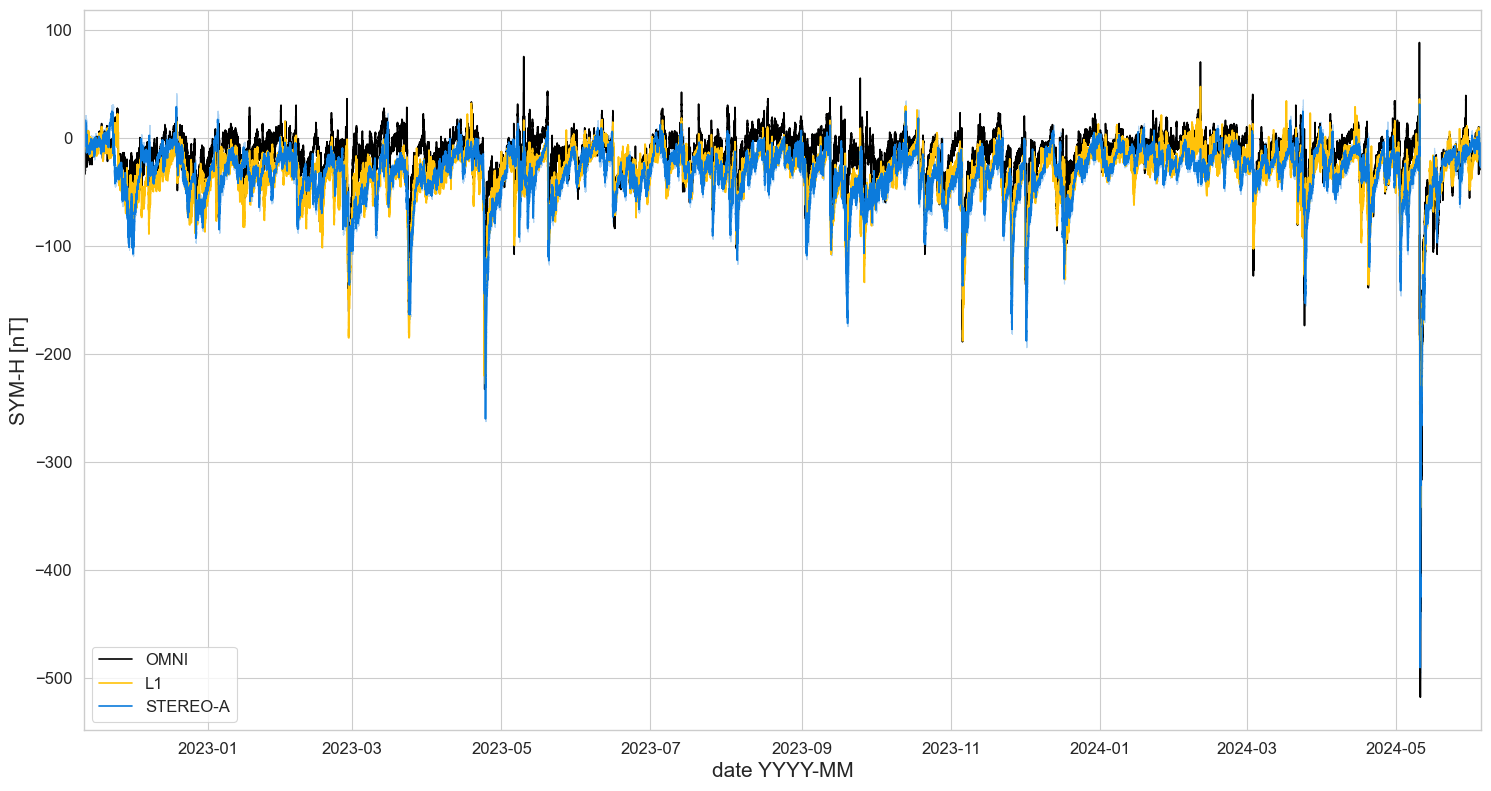

In [71]:
plt.figure(1, figsize=(15,8))
plt.plot(omni_input.time, omni_input.symh, color=c0, label='OMNI')
plt.plot(wind_generator.time, wind_generator.symh, color=c2, label='L1')
plt.fill_between(wind_generator.time, wind_generator.symh, wind_generator.symh, color=c2, alpha=0.3)
plt.plot(sc_fin_all['time'], sc_fin_all['symh'], color=c3, label='STEREO-A')
plt.fill_between(sc_fin_all['time'], sc_fin_all['symh']-np.abs(sc_fin_all['symh_err']), sc_fin_all['symh']+sc_fin_all['symh_err'], color=c3, alpha=0.3)
plt.xlim(omni_input.time[0], omni_input.time[-1])
plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)
plt.xlabel('date YYYY-MM', fontsize=15)
plt.ylabel('SYM-H [nT]', fontsize=15)
plt.legend(loc='lower left', fontsize=12)
plt.tight_layout()
#plt.savefig('symh_sta_l1_obs.png')

## Identify Peaks in SYM-H (< -50nT)

In [76]:
height_dst=50
#1440
indices_dst_sta = scipy.signal.find_peaks(-sc_fin_all['symh'], height=height_dst, distance=2160, prominence=60)[0] #scipy.signal.find_peaks(-sc_generator.symh, height=height_dst, distance=1300, prominence=70)[0]
indices_dst_l1 = scipy.signal.find_peaks(-wind_generator.symh, height=height_dst, distance=2160, prominence=60)[0] #original setting: distance=700, prominence=60
indices_dst_omni = scipy.signal.find_peaks(-omni_input.symh, height=height_dst, distance=2160, prominence=60)[0]

print('# geomagnetic storms with SYM-H < -50 nT: ', len(indices_dst_omni))
print('# pred. geomagnetic storms with SYM-H (L1) < -50 nT: ', len(indices_dst_l1))
print('# pred. geomagnetic storms with SYM-H (STA) < -50 nT: ', len(indices_dst_sta))

indices_both_sta=[]
indices_both_l1=[]
indices_both_omni=[]

time_window = 1.
time_window_l1 = 0.5

for i in indices_dst_sta:
    for k in indices_dst_omni:
        for j in indices_dst_l1:
            if (omni_input.time[k]-timedelta(days=time_window) <= sc_fin_all['time'][i] <= omni_input.time[k]+timedelta(days=time_window)) and (omni_input.time[k]-timedelta(days=time_window_l1) <= wind_generator['time'][j] <= omni_input.time[k]+timedelta(days=time_window_l1)):
                indices_both_sta.append(i)
                indices_both_omni.append(k)
                indices_both_l1.append(j)

                    
indices_obs_sta=[]
indices_obs_omni=[]
indices_obs_sta_3sig=[]
indices_obs_omni_3sig=[]
for i in indices_dst_sta:
    for k in indices_dst_omni:
        #for j in indices_dst_wind:
        if omni_input.time[k]-timedelta(days=time_window) <= sc_fin_all['time'][i] <= omni_input.time[k]+timedelta(days=time_window):
            indices_obs_sta.append(i)
            indices_obs_omni.append(k)
        if omni_input.time[k]-timedelta(hours=3*sc_fin_all['time_err'][i]) <= sc_fin_all['time'][i] <= omni_input.time[k]+timedelta(hours=3*sc_fin_all['time_err'][i]):
            indices_obs_sta_3sig.append(i)
            indices_obs_omni_3sig.append(k)
                    

#print(omni_input.time[indices_dst_omni])
#print(sc_generator.time[indices_dst_sta])

indices_obs_l1 = []
indices_obs_omni_l1 = []
for i in indices_dst_l1:
    for k in indices_dst_omni:
        #for j in indices_dst_wind:
        if omni_input.time[k]-timedelta(days=time_window_l1) <= wind_generator['time'][i] <= omni_input.time[k]+timedelta(days=time_window_l1):
            indices_obs_l1.append(i)
            indices_obs_omni_l1.append(k)

print('events L1 & OMNI: ', len(indices_obs_l1))
#print(len(sc_generator.time[indices_both_sta]))
#print(len(wind_generator.time[indices_both_wind]))
#print(len(omni_input.time[indices_both_omni]))

indices_l1_sta = []
indices_sta_l1 = []
for i in indices_dst_sta:
    #for k in indices_dst_omni:
    for j in indices_dst_l1:
            #if omni_input.time[k]-timedelta(days=time_window) <= sc_generator.time[i] <= omni_input.time[k]+timedelta(days=time_window):
        if wind_generator.time[j]-timedelta(days=time_window) <= sc_fin_all['time'][i] <= wind_generator.time[j]+timedelta(days=time_window):
            if j not in indices_obs_l1 and i not in indices_obs_sta:
                indices_l1_sta.append(j)
                indices_sta_l1.append(i)

print('events L1 & STA & OMNI: ', len(indices_both_sta))
print('events STA & OMNI: ', len(indices_obs_sta))#, len(indices_obs_omni))
print('events within 3 sigma: ', len(indices_obs_sta_3sig))#, len(indices_obs_omni_3sig))
print('events STA & L1: ', len(indices_l1_sta))
#plt.figure(1,figsize=(15,8))
#plt.plot(mdates.num2date(sc_0['time'][indices_dst_sta]), sc_0['dst'][indices_dst_sta], color='tab:blue', marker='o', linestyle=' ', ms=8)
#plt.plot(mdates.num2date(wind_0['time'][indices_dst_wind]), wind_0['dst'][indices_dst_wind], color='tab:green', marker='o', linestyle=' ', ms=8, alpha=0.7)
#plt.plot(mdates.num2date(omni_0['time'][indices_dst_omni]), omni_0['symh'][indices_dst_omni], color='tab:orange', marker='o', linestyle=' ', ms=8, alpha=0.7)
#plt.plot(mdates.num2date(omni_0['time'][indices_dst_sta]), omni_0['symh'][indices_dst_sta], color='tab:red', marker='o', linestyle=' ')
#plt.ylim(-300)
#plt.grid()



# geomagnetic storms with SYM-H < -50 nT:  47
# pred. geomagnetic storms with SYM-H (L1) < -50 nT:  50
# pred. geomagnetic storms with SYM-H (STA) < -50 nT:  35
events L1 & OMNI:  35
events L1 & STA & OMNI:  24
events STA & OMNI:  26
events within 3 sigma:  11
events STA & L1:  2


In [158]:
if beacon:
    if use_plasma == False:
        pickle.dump([indices_dst_sta, indices_dst_l1, indices_dst_omni, indices_obs_sta, indices_obs_omni, 
                     indices_obs_l1, indices_obs_omni_l1, indices_l1_sta, indices_sta_l1,
                    indices_both_sta, indices_both_l1, indices_both_omni], open(data_path+'indices_geomagnetic_storms_beacon.p', 'wb'))
    elif use_plasma==True:
        pickle.dump([indices_dst_sta, indices_dst_l1, indices_dst_omni, indices_obs_sta, indices_obs_omni, 
                     indices_obs_l1, indices_obs_omni_l1, indices_l1_sta, indices_sta_l1,
                    indices_both_sta, indices_both_l1, indices_both_omni], open(data_path+'indices_geomagnetic_storms_beacon_plasma.p', 'wb'))
else: pickle.dump([indices_dst_sta, indices_dst_l1, indices_dst_omni, indices_obs_sta, indices_obs_omni, 
                   indices_obs_l1, indices_obs_omni_l1, indices_l1_sta, indices_sta_l1,
                  indices_both_sta, indices_both_l1, indices_both_omni], open(data_path+'indices_geomagnetic_storms_science.p', 'wb'))